# Traffic Accident Risk Prediction System

## AI Challenge 6 – Traffic Accident Risk Predictor

### Project Overview

This project develops a machine learning-based system to predict traffic accident risk levels and identify dangerous road zones before accidents occur. The system analyzes historical accident records together with temporal, geographical, and road-related features to estimate accident severity and support proactive traffic safety management.

### Project Objectives

- Analyze road and traffic accident data.
- Predict accident risk levels using machine learning.
- Identify high-risk geographical areas.
- Adapt predictions to seasonal conditions.
- Reduce false alarms while maintaining reliable predictions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV,
    cross_val_score
)

from sklearn.preprocessing import OrdinalEncoder

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from sklearn.utils.class_weight import compute_class_weight

import lightgbm as lgb
from catboost import CatBoostClassifier

df = pd.read_csv("cleaned_us_accidents.csv")

In [2]:
print(df.shape)

(6764788, 27)


In [3]:
df.head()

,Source,Severity,Start_Lat,Start_Lng,Distance(mi),County,State,Amenity,Bump,Crossing,...,Traffic_Calming,Traffic_Signal,Turning_Loop,Year,Month,Day,Hour,DayOfWeek,Is_Weekend,Is_Rush_Hour
0,Source2,3,0.755481,0.619957,-0.555127,Montgomery,OH,0,0,0,...,0,0,False,2016,2,8,5,0,0,0
1,Source2,2,0.767917,0.690709,-0.555127,Franklin,OH,0,0,0,...,0,0,False,2016,2,8,6,0,0,0
2,Source2,2,0.596951,0.621462,-0.555127,Clermont,OH,0,0,0,...,0,1,False,2016,2,8,6,0,0,0
3,Source2,3,0.732276,0.611492,-0.555127,Montgomery,OH,0,0,0,...,0,0,False,2016,2,8,7,0,0,1
4,Source2,2,0.708561,0.612485,-0.555127,Montgomery,OH,0,0,0,...,0,1,False,2016,2,8,7,0,0,1


# 1. Data Quality Assessment

## 1.1 Missing Value Analysis

Before building the machine learning models, the dataset is examined for missing values. This step ensures that all features are complete and suitable for further analysis. Detecting missing values is essential because incomplete data can negatively affect model performance and lead to unreliable predictions.

In [4]:
missing = df.isnull().sum()
missing = missing[missing > 0]

print(missing.sort_values(ascending=False))

Series([], dtype: int64)


In [5]:
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_percent = missing_percent[missing_percent > 0]

print(missing_percent.sort_values(ascending=False))

Series([], dtype: float64)


### Analysis

The dataset contains no missing values after the data cleaning process. Both the absolute number and percentage of missing values are zero for all features, indicating that the dataset is complete and ready for feature engineering and machine learning without additional imputation.

## 1.2 Duplicate Record Analysis

In [6]:
print(df.duplicated().sum())

432126


In [7]:
df = df.drop_duplicates()
print(df.shape)
print(df.duplicated().sum())

(6332662, 27)
0


### Analysis

The dataset was checked for duplicate records and any duplicated observations were removed. After the cleaning process, the dataset contains only unique records, ensuring that repeated samples do not introduce bias into the machine learning models.

# 2. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to better understand the characteristics of the dataset before building machine learning models. This analysis explores the distribution of accident severity, temporal patterns, geographical characteristics, road infrastructure, and relationships between features to identify meaningful insights for risk prediction.

## 2.1 Target Variable Analysis

The target variable of this project is **Severity**, which represents the level of traffic accident severity. Analyzing its distribution helps identify class imbalance and provides insight into the prediction task before model training.

In [8]:
print(df["Severity"].value_counts())
print(round(df["Severity"].value_counts(normalize=True) * 100, 2))

Severity
2    4949904
3    1181985
4     140451
1      60322
Name: count, dtype: int64
Severity
2    78.16
3    18.66
4     2.22
1     0.95
Name: proportion, dtype: float64


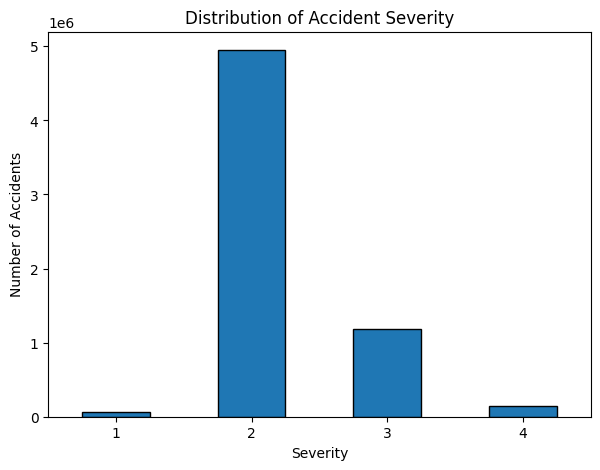

In [9]:
plt.figure(figsize=(7,5))

df["Severity"].value_counts().sort_index().plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Distribution of Accident Severity")
plt.xlabel("Severity")
plt.ylabel("Number of Accidents")

plt.xticks(rotation=0)

plt.show()

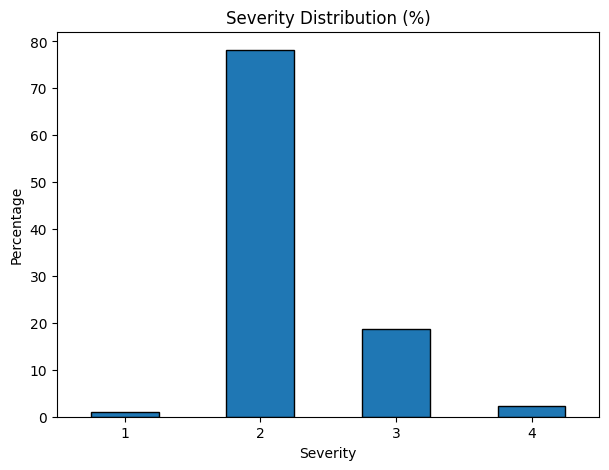

In [10]:
severity_percent = (
    df["Severity"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

plt.figure(figsize=(7,5))

severity_percent.plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Severity Distribution (%)")
plt.xlabel("Severity")
plt.ylabel("Percentage")

plt.xticks(rotation=0)

plt.show()

### Analysis

The target variable is highly imbalanced. Severity level **2** represents approximately **78%** of all recorded accidents, while severity level **3** accounts for nearly **19%**. The remaining classes (**Severity 1** and **Severity 4**) occur much less frequently.

Both the frequency and percentage distributions confirm a significant class imbalance, which is an important consideration during model evaluation. Therefore, in addition to overall accuracy, metrics such as precision, recall, and F1-score should also be used to assess model performance, particularly for minority classes.


## 2.2 Time-Based Analysis

Traffic accidents are influenced by temporal factors such as the hour of the day, day of the week, and seasonal variations. This section explores accident patterns over time to identify peak accident periods and understand how temporal features may affect accident occurrence and severity.

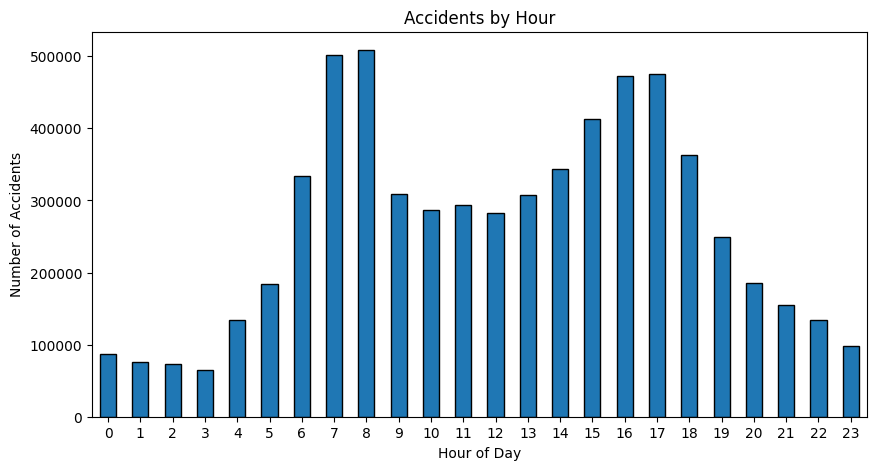

In [11]:
hour_counts = df["Hour"].value_counts().sort_index()

plt.figure(figsize=(10,5))
hour_counts.plot(kind="bar", edgecolor="black")

plt.title("Accidents by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Accidents")

plt.xticks(rotation=0)

plt.show()

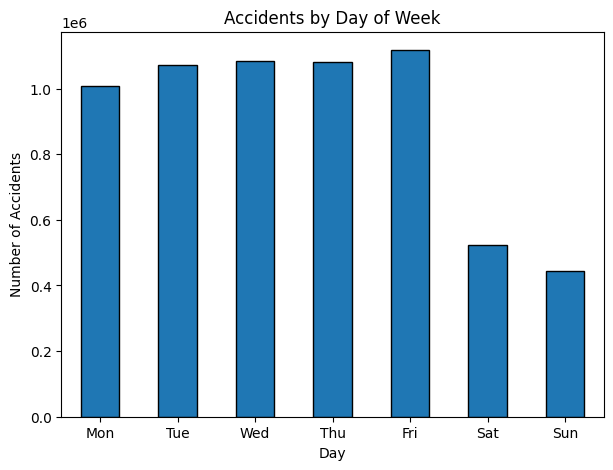

In [12]:
days = {
    0:"Mon",
    1:"Tue",
    2:"Wed",
    3:"Thu",
    4:"Fri",
    5:"Sat",
    6:"Sun"
}

day_counts = (
    df["DayOfWeek"]
    .value_counts()
    .sort_index()
)

day_counts.index = day_counts.index.map(days)

plt.figure(figsize=(7,5))
day_counts.plot(kind="bar", edgecolor="black")

plt.title("Accidents by Day of Week")
plt.xlabel("Day")
plt.ylabel("Number of Accidents")

plt.xticks(rotation=0)

plt.show()

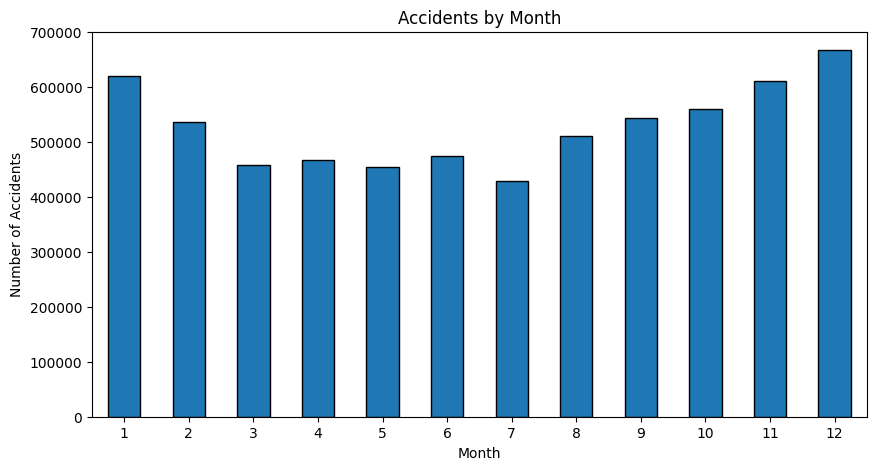

In [13]:
month_counts = (
    df["Month"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(10,5))

month_counts.plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Accidents by Month")
plt.xlabel("Month")
plt.ylabel("Number of Accidents")

plt.xticks(rotation=0)

plt.show()

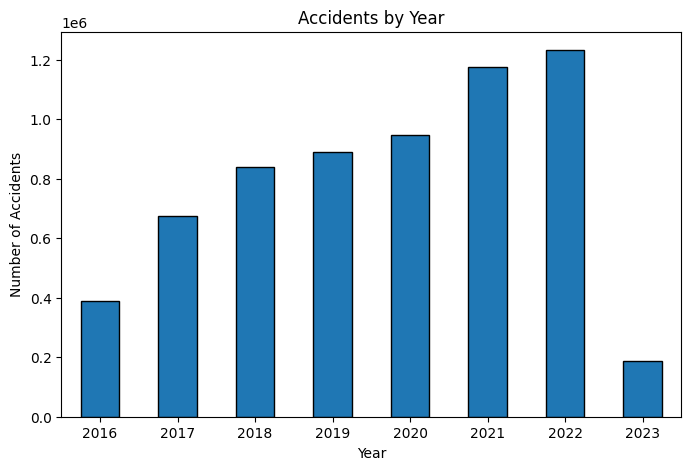

In [14]:
year_counts = (
    df["Year"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(8,5))

year_counts.plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Accidents by Year")
plt.xlabel("Year")
plt.ylabel("Number of Accidents")

plt.xticks(rotation=0)

plt.show()

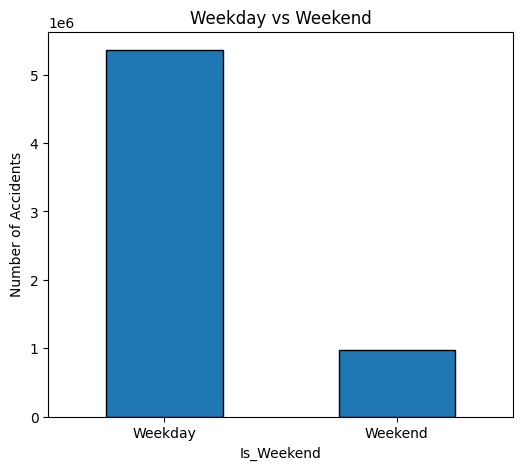

In [15]:
weekend = {
    0:"Weekday",
    1:"Weekend"
}

weekend_counts = (
    df["Is_Weekend"]
    .value_counts()
    .sort_index()
)

weekend_counts.index = weekend_counts.index.map(weekend)

plt.figure(figsize=(6,5))

weekend_counts.plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Weekday vs Weekend")
plt.ylabel("Number of Accidents")

plt.xticks(rotation=0)

plt.show()

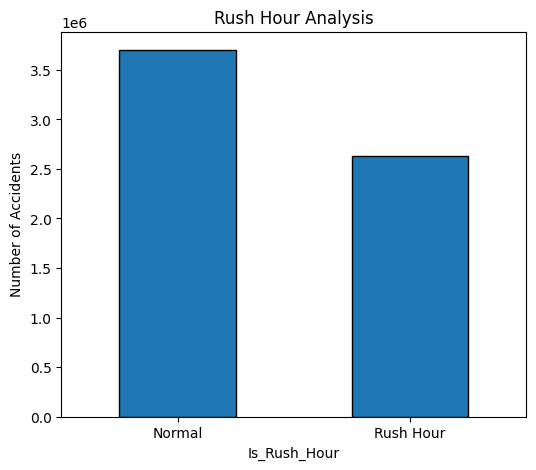

In [16]:
rush = {
    0:"Normal",
    1:"Rush Hour"
}

rush_counts = (
    df["Is_Rush_Hour"]
    .value_counts()
    .sort_index()
)

rush_counts.index = rush_counts.index.map(rush)

plt.figure(figsize=(6,5))

rush_counts.plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Rush Hour Analysis")
plt.ylabel("Number of Accidents")

plt.xticks(rotation=0)

plt.show()

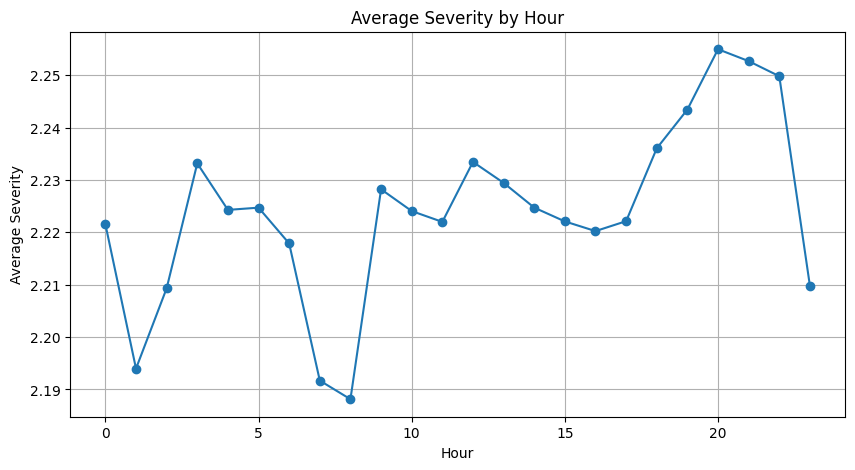

In [17]:
severity_hour = (
    df.groupby("Hour")["Severity"]
      .mean()
)

plt.figure(figsize=(10,5))

severity_hour.plot(
    kind="line",
    marker="o"
)

plt.title("Average Severity by Hour")
plt.xlabel("Hour")
plt.ylabel("Average Severity")

plt.grid(True)

plt.show()

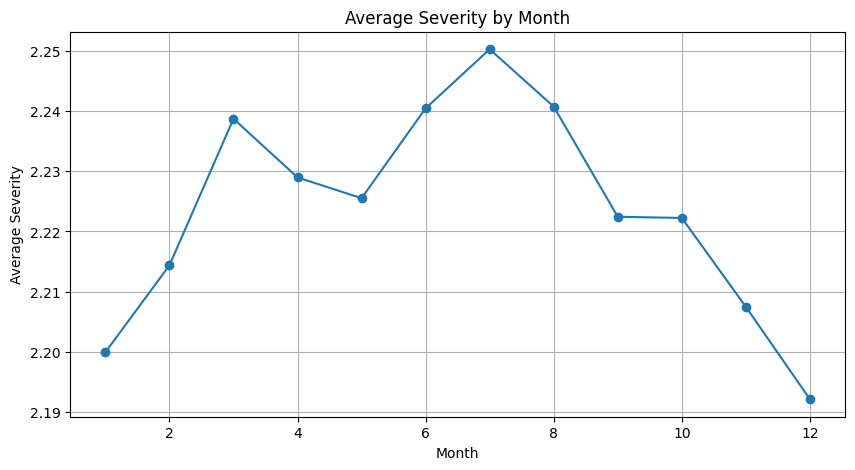

In [18]:
severity_month = (
    df.groupby("Month")["Severity"]
      .mean()
)

plt.figure(figsize=(10,5))

severity_month.plot(
    kind="line",
    marker="o"
)

plt.title("Average Severity by Month")
plt.xlabel("Month")
plt.ylabel("Average Severity")

plt.grid(True)

plt.show()

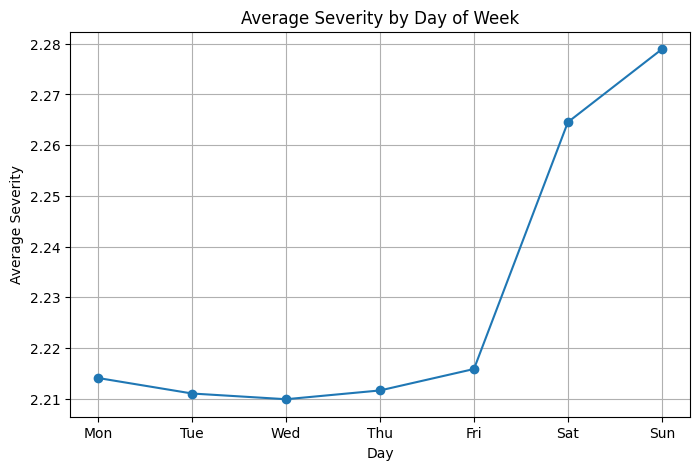

In [19]:
days = {
    0:"Mon",
    1:"Tue",
    2:"Wed",
    3:"Thu",
    4:"Fri",
    5:"Sat",
    6:"Sun"
}

severity_day = (
    df.groupby("DayOfWeek")["Severity"]
      .mean()
)

severity_day.index = severity_day.index.map(days)

plt.figure(figsize=(8,5))

severity_day.plot(
    kind="line",
    marker="o"
)

plt.title("Average Severity by Day of Week")
plt.xlabel("Day")
plt.ylabel("Average Severity")

plt.grid(True)

plt.show()

### Analysis

The temporal analysis reveals several important accident patterns. Accident frequency changes considerably across different hours of the day, indicating that traffic conditions and human activities strongly influence accident occurrence. The distributions by weekday and weekend also show that accidents are not evenly distributed throughout the week, suggesting differences in traffic volume and travel behavior.

Monthly and yearly trends demonstrate that accident frequency varies over time, which may be related to changes in traffic demand, weather conditions, or data collection coverage. Additionally, the comparison between rush hours and normal hours shows that a substantial portion of accidents occurs outside traditional commuting periods. Therefore, time-related features such as **Year**, **Month**, **DayOfWeek**, **Hour**, **Is_Weekend**, and **Is_Rush_Hour** are valuable predictors and are retained for machine learning model development.

## 2.3 Geographic Analysis

Geographical factors play a significant role in traffic accident patterns. This section explores the spatial distribution of accidents across different states and counties to identify high-risk regions and understand how accident frequency and severity vary by location.

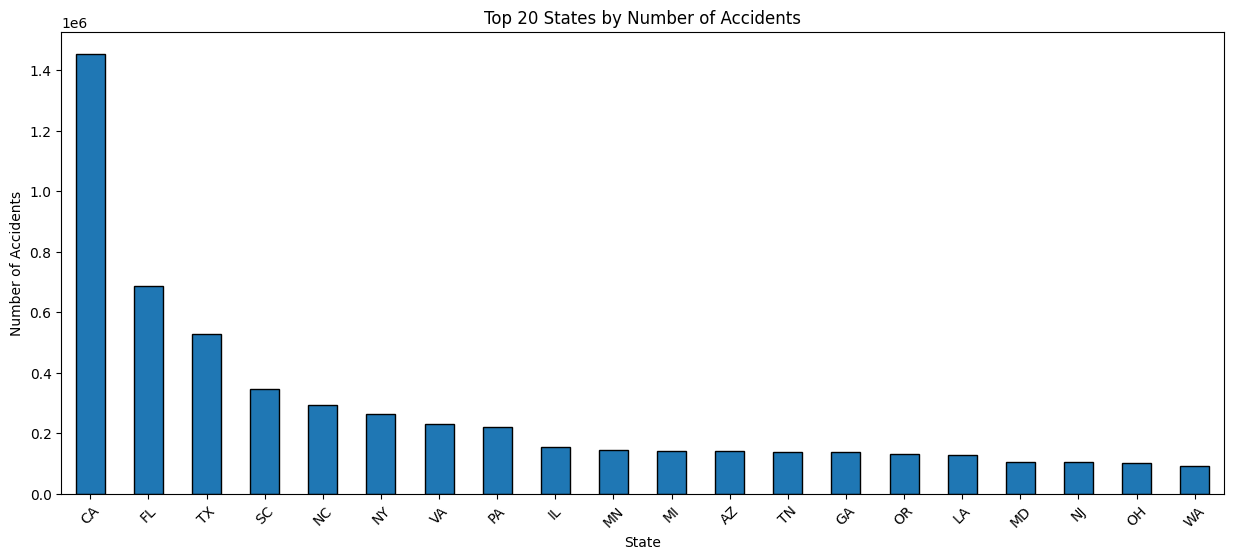

In [20]:
state_counts = (
    df["State"]
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(15,6))

state_counts.head(20).plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Top 20 States by Number of Accidents")
plt.xlabel("State")
plt.ylabel("Number of Accidents")

plt.xticks(rotation=45)

plt.show()

In [21]:
state_counts.head(20)

State
CA    1454815
FL     686360
TX     527048
SC     347333
NC     293099
NY     263074
VA     229906
PA     221257
IL     153257
MN     144936
MI     141113
AZ     139705
TN     138826
GA     138483
OR     131366
LA     129645
MD     105369
NJ     104318
OH     101049
WA      92926
Name: count, dtype: int64

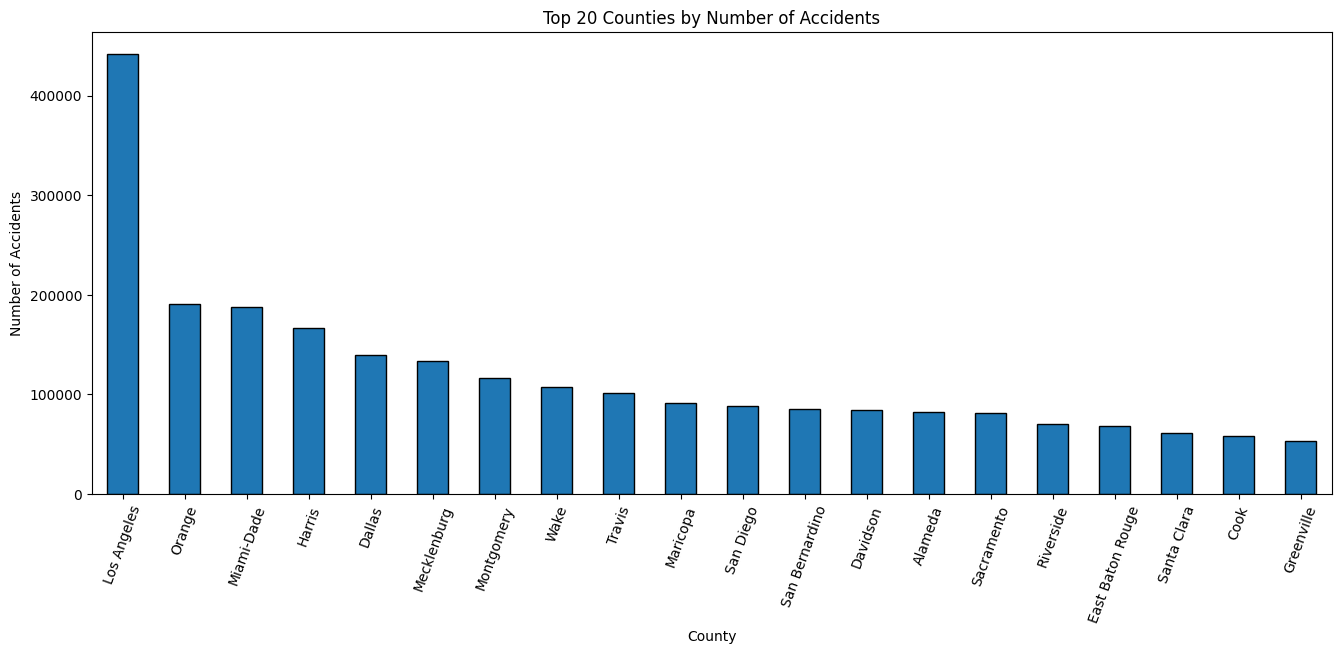

In [22]:
county_counts = (
    df["County"]
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(16,6))

county_counts.head(20).plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Top 20 Counties by Number of Accidents")
plt.xlabel("County")
plt.ylabel("Number of Accidents")

plt.xticks(rotation=70)

plt.show()

In [23]:
county_counts.head(20)

County
Los Angeles         441817
Orange              191096
Miami-Dade          187488
Harris              166221
Dallas              139117
Mecklenburg         133608
Montgomery          116932
Wake                107269
Travis              101308
Maricopa             91161
San Diego            87926
San Bernardino       85844
Davidson             84186
Alameda              82023
Sacramento           81774
Riverside            69965
East Baton Rouge     68570
Santa Clara          60817
Cook                 58215
Greenville           52946
Name: count, dtype: int64

### Average Severity

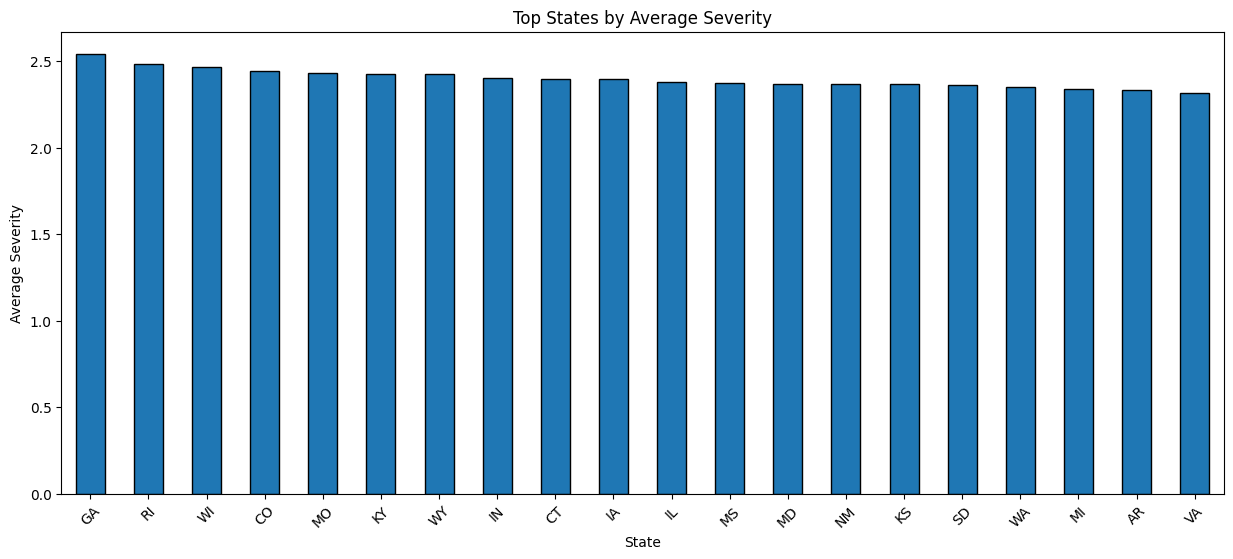

In [24]:
severity_state = (
    df.groupby("State")["Severity"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(15,6))

severity_state.head(20).plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Top States by Average Severity")
plt.xlabel("State")
plt.ylabel("Average Severity")

plt.xticks(rotation=45)

plt.show()

In [25]:
severity_state.head(20)

State
GA    2.543229
RI    2.480686
WI    2.467238
CO    2.441972
MO    2.431325
KY    2.428302
WY    2.426526
IN    2.402066
CT    2.395818
IA    2.395376
IL    2.377927
MS    2.374749
MD    2.366996
NM    2.366408
KS    2.365370
SD    2.362637
WA    2.350612
MI    2.339246
AR    2.335042
VA    2.317704
Name: Severity, dtype: float64

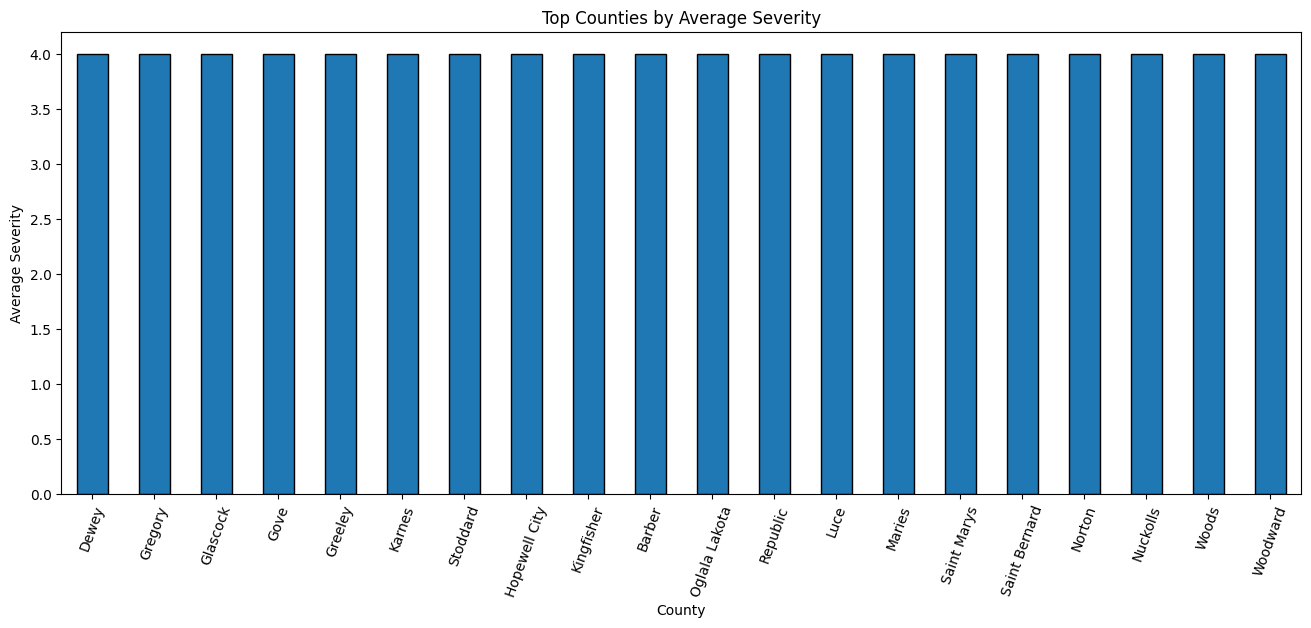

In [26]:
severity_county = (
    df.groupby("County")["Severity"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(16,6))

severity_county.head(20).plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Top Counties by Average Severity")
plt.xlabel("County")
plt.ylabel("Average Severity")

plt.xticks(rotation=70)

plt.show()

In [27]:
severity_county.head(20)

County
Dewey            4.0
Gregory          4.0
Glascock         4.0
Gove             4.0
Greeley          4.0
Karnes           4.0
Stoddard         4.0
Hopewell City    4.0
Kingfisher       4.0
Barber           4.0
Oglala Lakota    4.0
Republic         4.0
Luce             4.0
Maries           4.0
Saint Marys      4.0
Saint Bernard    4.0
Norton           4.0
Nuckolls         4.0
Woods            4.0
Woodward         4.0
Name: Severity, dtype: float64

### High-Risk Regions Summary

In [28]:
high_risk = (
    df.groupby(["State","County"])
      .agg(
          Accident_Count=("Severity","count"),
          Average_Severity=("Severity","mean")
      )
      .sort_values(
          by=["Accident_Count","Average_Severity"],
          ascending=False
      )
)

high_risk.head(20)

Accident_Count  Average_Severity
State County                                            
CA    Los Angeles               441817          2.263734
FL    Miami-Dade                187488          2.101030
TX    Harris                    166029          2.198899
      Dallas                    138326          2.313621
NC    Mecklenburg               132499          2.045872
      Wake                      107269          2.091741
TX    Travis                    101308          2.088117
FL    Orange                     97850          2.084088
AZ    Maricopa                   91161          2.131295
CA    San Diego                  87926          2.244137
      Orange                     87239          2.204324
      San Bernardino             85844          2.227797
TN    Davidson                   83307          2.139304
CA    Alameda                    82023          2.365641
      Sacramento                 81774          2.093930
      Riverside                  69965          2.179861
LA    East Baton Rouge           68570          2.080662
CA    Santa Clara                60817          2.147261
PA    Montgomery                 59810          2.050109
IL    Cook                       58056          2.565799

## 2.4 Road Infrastructure Analysis

Road infrastructure elements can significantly influence both the occurrence and severity of traffic accidents. This section investigates how frequently different road features appear in accident records and whether certain road characteristics are associated with higher accident severity.

### Feature Occurrence

In [29]:
road_features = [
    "Amenity",
    "Bump",
    "Crossing",
    "Give_Way",
    "Junction",
    "No_Exit",
    "Railway",
    "Roundabout",
    "Station",
    "Stop",
    "Traffic_Calming",
    "Traffic_Signal"
]

feature_percent = (
    df[road_features].mean()*100
).sort_values(ascending=False)

print(feature_percent)

Traffic_Signal     16.869857
Crossing           12.536971
Junction            7.102037
Stop                3.018762
Station             2.795286
Amenity             1.375820
Railway             0.950753
Give_Way            0.508017
No_Exit             0.271087
Traffic_Calming     0.104506
Bump                0.047673
Roundabout          0.003837
dtype: float64


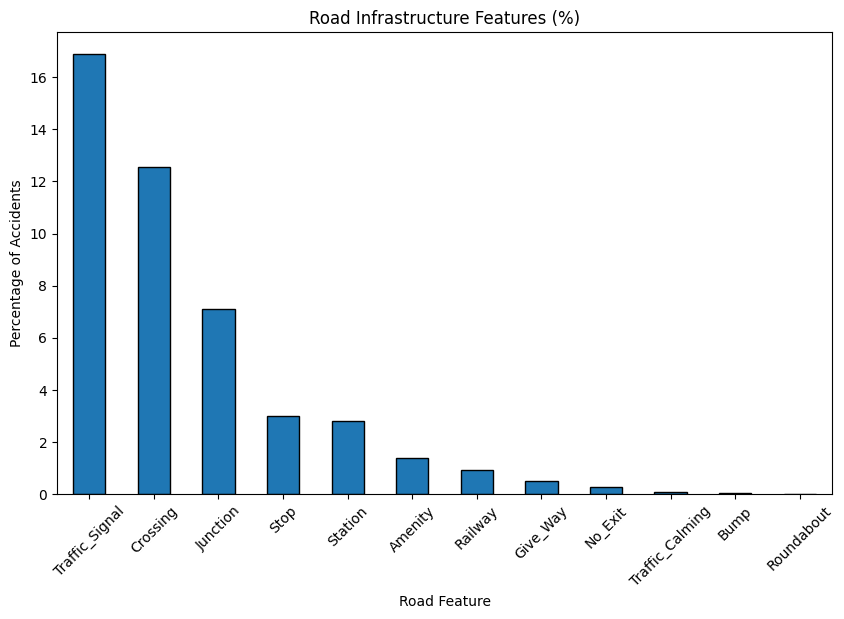

In [30]:
plt.figure(figsize=(10,6))

feature_percent.plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Road Infrastructure Features (%)")
plt.xlabel("Road Feature")
plt.ylabel("Percentage of Accidents")

plt.xticks(rotation=45)

plt.show()

### Average Severity

In [31]:
severity_by_feature = {}

for feature in road_features:
    severity_by_feature[feature] = (
        df.groupby(feature)["Severity"]
          .mean()[1]
    )

severity_df = (
    pd.DataFrame(
        severity_by_feature.items(),
        columns=["Feature", "Average Severity"]
    )
    .sort_values("Average Severity", ascending=False)
)

severity_df

,Feature,Average Severity
4,Junction,2.323032
3,Give_Way,2.170371
6,Railway,2.161656
10,Traffic_Calming,2.131006
5,No_Exit,2.113707
1,Bump,2.095396
11,Traffic_Signal,2.085970
8,Station,2.080055
0,Amenity,2.066616
9,Stop,2.065351


In [32]:
severity_df = (
    pd.DataFrame(
        severity_by_feature.items(),
        columns=["Feature","Average Severity"]
    )
)

severity_df = severity_df.sort_values(
    by="Average Severity",
    ascending=False
)

severity_df

,Feature,Average Severity
4,Junction,2.323032
3,Give_Way,2.170371
6,Railway,2.161656
10,Traffic_Calming,2.131006
5,No_Exit,2.113707
1,Bump,2.095396
11,Traffic_Signal,2.085970
8,Station,2.080055
0,Amenity,2.066616
9,Stop,2.065351


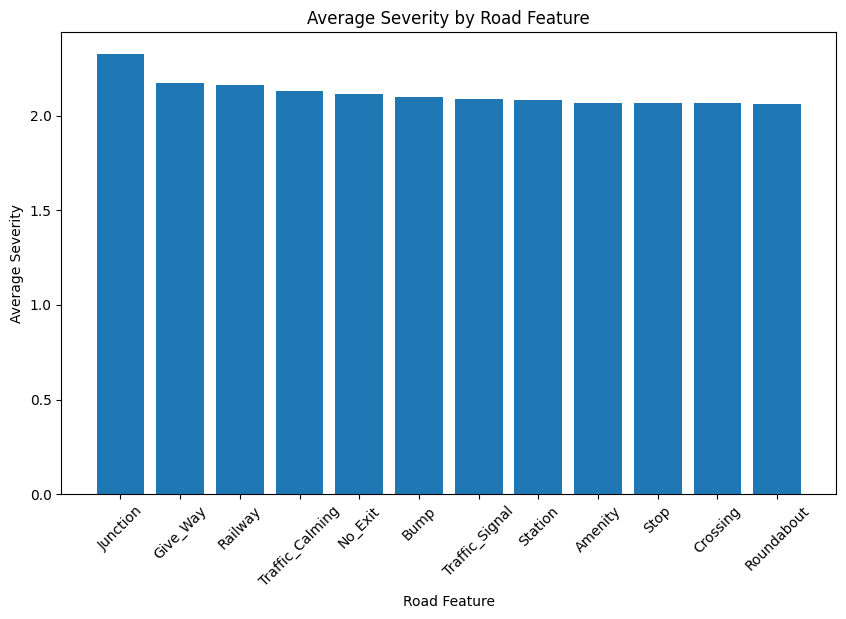

In [33]:
plt.figure(figsize=(10,6))

plt.bar(
    severity_df["Feature"],
    severity_df["Average Severity"]
)

plt.title("Average Severity by Road Feature")
plt.xlabel("Road Feature")
plt.ylabel("Average Severity")

plt.xticks(rotation=45)

plt.show()

### Road Infrastructure Summary

In [34]:
road_summary = []

for feature in road_features:
    road_summary.append({
        "Feature": feature,
        "Accident_Count": df[feature].sum(),
        "Accident_Percentage": round(df[feature].mean() * 100, 2),
        "Average_Severity": df.loc[df[feature] == 1, "Severity"].mean()
    })

road_summary = pd.DataFrame(road_summary)

road_summary = road_summary.sort_values(
    by="Average_Severity",
    ascending=False
)

road_summary

,Feature,Accident_Count,Accident_Percentage,Average_Severity
4,Junction,449748,7.10,2.323032
3,Give_Way,32171,0.51,2.170371
6,Railway,60208,0.95,2.161656
10,Traffic_Calming,6618,0.10,2.131006
5,No_Exit,17167,0.27,2.113707
1,Bump,3019,0.05,2.095396
11,Traffic_Signal,1068311,16.87,2.085970
8,Station,177016,2.80,2.080055
0,Amenity,87126,1.38,2.066616
9,Stop,191168,3.02,2.065351


### Analysis

The road infrastructure analysis reveals that some road features are involved in accidents much more frequently than others. Traffic signals, crossings, and junctions appear in a large proportion of accident records, indicating that these locations experience high traffic activity and therefore more accident occurrences.

However, accident frequency does not necessarily imply higher accident severity. The average severity analysis shows that **junctions** have the highest mean accident severity among all examined road features, followed by **give-way intersections** and **railway crossings**. In contrast, although **traffic signals** and **crossings** are among the most common road features, their average severity is relatively lower.

These findings suggest that different road infrastructure elements contribute differently to accident outcomes. Consequently, road-related features provide valuable information for predicting accident severity and are retained as important predictors in the machine learning models.

## 2.5 Numerical Feature Analysis

Numerical features provide quantitative information that may influence accident severity. This section examines the distributions of numerical variables and investigates how these features vary across different accident severity levels.

### Feature Distributions

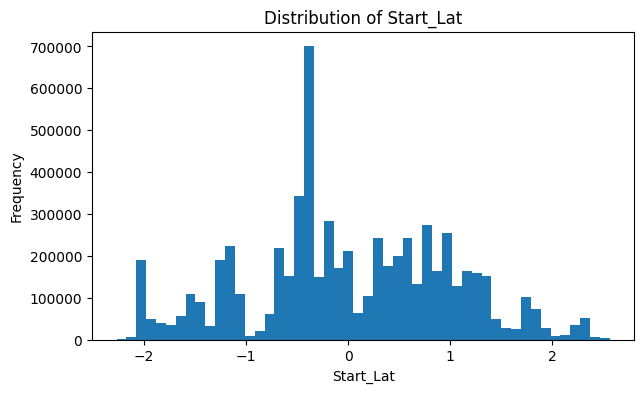

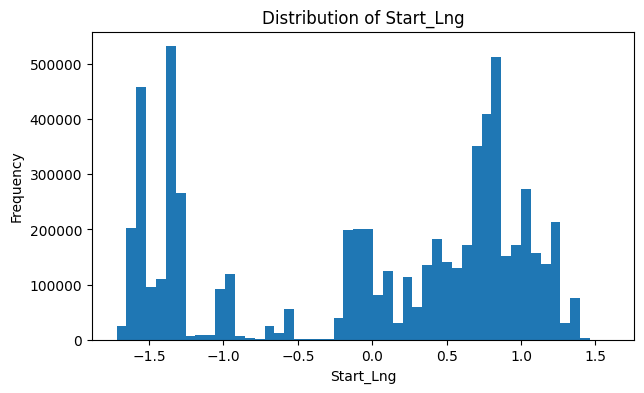

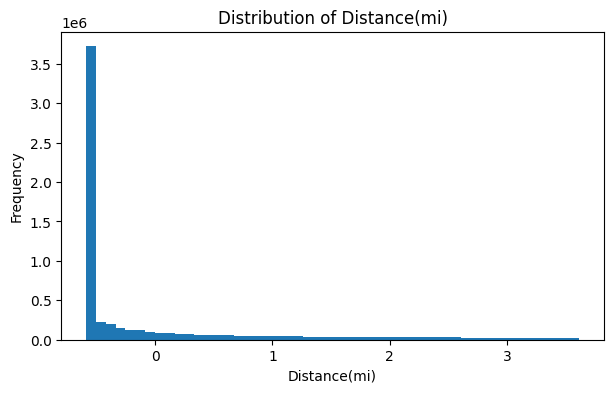

In [35]:
numerical_features = [
    "Start_Lat",
    "Start_Lng",
    "Distance(mi)"
]

for feature in numerical_features:

    plt.figure(figsize=(7,4))

    plt.hist(df[feature], bins=50)

    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")

    plt.show()

### Summary Statistics

In [36]:
df[numerical_features].describe()

,Start_Lat,Start_Lng,Distance(mi)
count,6.332662e+06,6.332662e+06,6.332662e+06
mean,1.204292e-02,-7.539393e-03,-1.894737e-02
std,9.891959e-01,9.975601e-01,9.996964e-01
min,-2.270900e+00,-1.718125e+00,-5.914040e-01
25%,-5.396535e-01,-1.293240e+00,-5.914040e-01
50%,-8.748073e-02,3.937671e-01,-5.914040e-01
75%,7.737018e-01,8.131061e-01,1.051145e-01
max,2.561594e+00,1.596661e+00,3.616729e+00


### Average Values by Severity

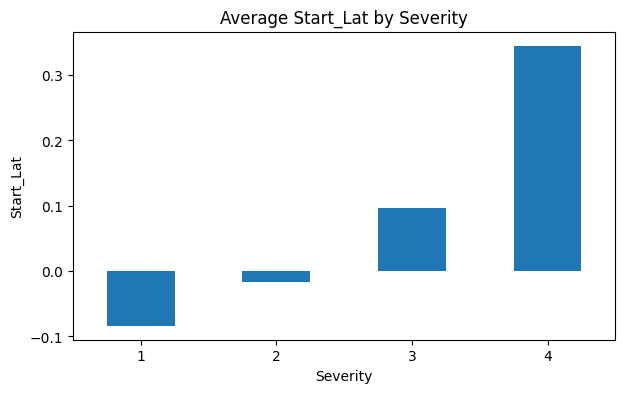

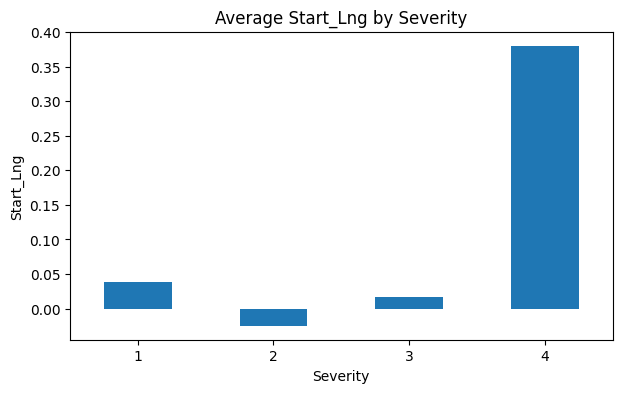

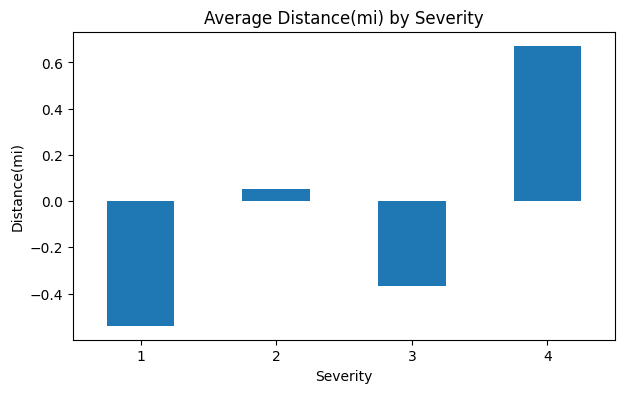

In [37]:
for feature in numerical_features:

    plt.figure(figsize=(7,4))

    df.groupby("Severity")[feature].mean().plot(
        kind="bar"
    )

    plt.title(f"Average {feature} by Severity")

    plt.ylabel(feature)

    plt.xticks(rotation=0)

    plt.show()

In [38]:
severity_numeric = (
    df.groupby("Severity")[numerical_features]
      .mean()
)

severity_numeric

,Start_Lat,Start_Lng,Distance(mi)
Severity,,,
1,-0.083586,0.038994,-0.539230
2,-0.016329,-0.024891,0.050678
3,0.096185,0.016657,-0.366104
4,0.344917,0.380383,0.672256


### Analysis

The numerical feature analysis shows that the selected numerical variables exhibit different distributions and value ranges across the dataset. The descriptive statistics indicate that the features have already been standardized, making them suitable for machine learning algorithms without requiring additional scaling.

When comparing the average values across accident severity levels, noticeable differences can be observed among the severity classes. In particular, **Distance(mi)** shows the clearest variation, suggesting that longer accidents are generally associated with higher severity levels. Geographic coordinates (**Start_Lat** and **Start_Lng**) also vary across severity groups, indicating that accident severity differs by location.

Overall, the numerical variables contain useful predictive information and are retained as input features for the machine learning models.

## 2.6 Correlation Analysis

Correlation analysis is used to measure the linear relationship between numerical variables. This section explores how individual features are associated with the target variable (**Severity**) and identifies variables that may contribute to accident severity prediction.

### Correlation Matrix

In [39]:
correlation = df.corr(numeric_only=True)

correlation

,Severity,Start_Lat,Start_Lng,Distance(mi),Amenity,Bump,Crossing,Give_Way,Junction,No_Exit,...,Traffic_Calming,Traffic_Signal,Turning_Loop,Year,Month,Day,Hour,DayOfWeek,Is_Weekend,Is_Rush_Hour
Severity,1.000000,0.065326,0.043927,-0.060106,-0.037665,-0.005670,-0.122977,-0.007521,0.057819,-0.011571,...,-0.006026,-0.125703,NaN,-0.215523,-0.006808,0.000996,0.021050,0.031256,0.043464,-0.016377
Start_Lat,0.065326,1.000000,-0.065506,0.056310,0.028022,-0.001481,-0.058916,0.000026,0.052366,-0.003280,...,-0.003591,-0.065878,NaN,-0.037771,0.000023,0.003540,-0.009506,0.014046,0.018877,0.006678
Start_Lng,0.043927,-0.065506,1.000000,-0.002121,0.007249,-0.012572,0.059881,0.024459,-0.048241,0.007126,...,-0.001841,0.080174,NaN,0.045731,0.015096,-0.001027,-0.013082,-0.050969,-0.070665,0.061134
Distance(mi),-0.060106,0.056310,-0.002121,1.000000,-0.037896,-0.004079,-0.129321,-0.021779,0.111666,-0.009450,...,-0.007210,-0.184518,NaN,0.269676,0.010309,0.003108,0.032294,0.052871,0.064780,-0.056379
Amenity,-0.037665,0.028022,0.007249,-0.037896,1.000000,0.006239,0.149103,0.006262,-0.027015,0.013396,...,0.025423,0.103796,NaN,-0.007525,0.002219,-0.000666,0.003409,-0.005390,-0.009097,0.000288
Bump,-0.005670,-0.001481,-0.012572,-0.004079,0.006239,1.000000,0.010912,0.000474,-0.004546,0.016113,...,0.675219,-0.005299,NaN,0.006048,-0.000013,-0.000060,0.001214,0.001256,0.001928,-0.001307
Crossing,-0.122977,-0.058916,0.059881,-0.129321,0.149103,0.010912,1.000000,0.059529,-0.091710,0.062034,...,0.037212,0.478504,NaN,-0.033507,0.001656,-0.001363,-0.001401,-0.037689,-0.051648,0.022812
Give_Way,-0.007521,0.000026,0.024459,-0.021779,0.006262,0.000474,0.059529,1.000000,-0.010574,0.006100,...,0.003257,0.072829,NaN,-0.012361,0.000700,-0.000223,-0.000299,-0.005729,-0.007734,0.004316
Junction,0.057819,0.052366,-0.048241,0.111666,-0.027015,-0.004546,-0.091710,-0.010574,1.000000,-0.004105,...,-0.005061,-0.111244,NaN,-0.047690,-0.009251,0.000524,-0.001706,0.009717,0.012468,-0.009228
No_Exit,-0.011571,-0.003280,0.007126,-0.009450,0.013396,0.016113,0.062034,0.006100,-0.004105,1.000000,...,0.013541,0.029779,NaN,0.001703,0.000047,-0.000548,0.001296,-0.003822,-0.005401,0.002724


### Correlation with Severity

In [40]:
severity_corr = (
    correlation["Severity"]
    .sort_values(ascending=False)
)

print(severity_corr)

Severity           1.000000
Start_Lat          0.065326
Junction           0.057819
Start_Lng          0.043927
Is_Weekend         0.043464
DayOfWeek          0.031256
Hour               0.021050
Day                0.000996
Roundabout        -0.002038
Bump              -0.005670
Traffic_Calming   -0.006026
Month             -0.006808
Give_Way          -0.007521
No_Exit           -0.011571
Railway           -0.012069
Is_Rush_Hour      -0.016377
Amenity           -0.037665
Station           -0.049385
Stop              -0.056722
Distance(mi)      -0.060106
Crossing          -0.122977
Traffic_Signal    -0.125703
Year              -0.215523
Turning_Loop            NaN
Name: Severity, dtype: float64


### Correlation without Severity

In [41]:
correlation = df.corr(numeric_only=True)

severity_corr = (
    correlation["Severity"]
    .drop("Severity")
    .sort_values(ascending=False)
)

print("Top 10 Positive Correlations")
display(severity_corr.head(10).to_frame(name="Correlation"))

print("Top 10 Negative Correlations")
display(severity_corr.tail(10).to_frame(name="Correlation"))

Top 10 Positive Correlations


,Correlation
Start_Lat,0.065326
Junction,0.057819
Start_Lng,0.043927
Is_Weekend,0.043464
DayOfWeek,0.031256
Hour,0.021050
Day,0.000996
Roundabout,-0.002038
Bump,-0.005670
Traffic_Calming,-0.006026


Top 10 Negative Correlations


,Correlation
Railway,-0.012069
Is_Rush_Hour,-0.016377
Amenity,-0.037665
Station,-0.049385
Stop,-0.056722
Distance(mi),-0.060106
Crossing,-0.122977
Traffic_Signal,-0.125703
Year,-0.215523
Turning_Loop,NaN


### Analysis

The correlation analysis indicates that no individual feature has a strong linear relationship with accident severity. The highest positive correlations are observed for **Start_Lat**, **Junction**, **Start_Lng**, **Is_Weekend**, and **DayOfWeek**, while **Year**, **Traffic_Signal**, **Crossing**, and **Distance(mi)** show the strongest negative correlations.

Although several variables exhibit measurable correlations, all correlation coefficients are relatively small in magnitude. This suggests that accident severity is influenced by the combined effect of multiple factors rather than by a single feature.

These findings support the use of tree-based machine learning models, such as Decision Tree, Random Forest, LightGBM, and CatBoost, which can capture complex and non-linear relationships between features more effectively than linear models.

## EDA Summary

The table below summarizes the main findings from the exploratory data analysis. These insights provide a concise overview of the dataset characteristics and support the feature selection process for the subsequent machine learning models.

In [42]:
eda_summary = pd.DataFrame({
    "Section": [
        "Target Analysis",
        "Time Analysis",
        "Geographic Analysis",
        "Road Analysis",
        "Numerical Analysis",
        "Correlation Analysis"
    ],
    "Key Finding": [
        "Severity class 2 is the dominant class (~78%).",
        "Accidents are more frequent during non-rush hours in this dataset.",
        "California and Los Angeles County have the highest accident counts.",
        "Junctions have the highest average accident severity.",
        "Distance(mi) shows the largest variation across severity levels.",
        "No single feature has a strong linear correlation with Severity."
    ]
})

eda_summary

,Section,Key Finding
0,Target Analysis,Severity class 2 is the dominant class (~78%).
1,Time Analysis,Accidents are more frequent during non-rush ho...
2,Geographic Analysis,California and Los Angeles County have the hig...
3,Road Analysis,Junctions have the highest average accident se...
4,Numerical Analysis,Distance(mi) shows the largest variation acros...
5,Correlation Analysis,No single feature has a strong linear correlat...


# 3. Machine Learning

This section focuses on building machine learning models to predict accident severity. The workflow includes feature selection, data preprocessing, model training, evaluation, and comparison of multiple classification algorithms.

## 3.1 Feature Selection

In [43]:
X = df.drop(columns=["Severity"])
y = df["Severity"]

print("X Shape:", X.shape)
print("y Shape:", y.shape)

print("\nObject Columns:")
print(X.select_dtypes(include="object").columns)

X Shape: (6332662, 26)
y Shape: (6332662,)

Object Columns:
Index(['Source', 'County', 'State'], dtype='object')


## 3.2 Train-Test Split

To evaluate the machine learning models fairly, the dataset is divided into training and testing sets. A stratified split is used to preserve the original distribution of accident severity classes in both subsets.

In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (5066129, 26)
X_test : (1266533, 26)
y_train: (5066129,)
y_test : (1266533,)


### Result

The dataset was successfully split into training (80%) and testing (20%) subsets. Using stratified sampling ensures that the class distribution remains consistent across both sets, reducing potential bias during model evaluation.

## 3.3 Categorical Feature Encoding

Machine learning models require numerical input features. Therefore, the categorical variables (**Source**, **County**, and **State**) are encoded using an **OrdinalEncoder**. Unknown categories appearing in the test set are assigned a value of **-1**, ensuring that the encoding process remains robust when unseen labels are encountered.

In [45]:
encoder = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

categorical_cols = ["Source", "County", "State"]

X_train[categorical_cols] = encoder.fit_transform(X_train[categorical_cols])

X_test[categorical_cols] = encoder.transform(X_test[categorical_cols])

### Result

All categorical features were successfully converted into numerical values using **OrdinalEncoder**. This approach ensures compatibility with machine learning algorithms while safely handling previously unseen categories in the test set.

## 3.4 Hyperparameter Tuning

To improve the performance of the Random Forest classifier, hyperparameter optimization was performed using **RandomizedSearchCV**. A representative subset of the training data was selected to reduce computational cost while maintaining sufficient data diversity. The best parameter combination was selected based on the weighted F1-score obtained through 3-fold cross-validation.

In [46]:
X_sample = X_train.sample(n=300000, random_state=42)
y_sample = y_train.loc[X_sample.index]

param_dist = {
    "n_estimators": [100, 200, 300],
    "max_depth": [20, 30, 40, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

rf = RandomForestClassifier(
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    scoring="f1_weighted",
    random_state=42,
    verbose=2,
    n_jobs=-1
)

random_search.fit(X_sample, y_sample)

print("Best Parameters:")
print(random_search.best_params_)

print("\nBest CV Score:")
print(random_search.best_score_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Parameters:
{'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 40}

Best CV Score:
0.8462933011436354


### Result

The hyperparameter search identified an optimized set of parameters for the Random Forest classifier. These optimized values were used to build the final model in the subsequent training step, aiming to improve predictive performance while reducing the risk of overfitting.

## 3.5 Random Forest Model
The Random Forest classifier was trained using the optimized hyperparameters obtained from the previous tuning process. Class weights were balanced to mitigate the effect of class imbalance, and parallel processing was enabled to improve training efficiency.

In [47]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=40,
    min_samples_split=5,
    min_samples_leaf=1,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

### Model Training

The Random Forest classifier is trained using the prepared training dataset and the optimized hyperparameters obtained from the tuning process.

In [48]:
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,40
,min_samples_split,5
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Model Prediction

After training, the fitted model is used to predict accident severity for the unseen test dataset.

In [49]:
y_pred = rf_model.predict(X_test)

### Model Evaluation

The trained Random Forest model is evaluated using multiple classification metrics. In addition to overall accuracy, precision, recall, F1-score, and the confusion matrix are reported to provide a comprehensive assessment of the model's performance on the test dataset.

In [50]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)

print(cm)

Accuracy: 0.8863243200137699
              precision    recall  f1-score   support

           1       0.65      0.78      0.71     12065
           2       0.94      0.92      0.93    989981
           3       0.75      0.80      0.77    236397
           4       0.44      0.37      0.40     28090

    accuracy                           0.89   1266533
   macro avg       0.69      0.72      0.70   1266533
weighted avg       0.89      0.89      0.89   1266533

[[  9451   1840    746     28]
 [  3887 914515  59866  11713]
 [  1217  45314 188334   1532]
 [    76  16029   1726  10259]]


### Evaluation Summary

The optimized Random Forest classifier achieved an overall **accuracy of 88.63%** on the test dataset, demonstrating strong predictive performance for accident severity classification.

The model performs exceptionally well for the dominant **Severity 2** class, achieving high precision and recall. It also provides good predictive performance for **Severity 3**, with a balanced precision and recall.

For the minority classes (**Severity 1** and **Severity 4**), the model achieves lower performance, particularly for **Severity 4**. This behavior is expected due to the highly imbalanced class distribution within the dataset, where severe accidents occur much less frequently than moderate ones.

Overall, the optimized Random Forest model provides a strong balance between overall accuracy and class-wise performance, making it a reliable baseline for comparison with the remaining machine learning models.

### Cross-Validation

To evaluate the stability and generalization ability of the Random Forest model, 5-fold cross-validation is performed on a representative subset of the training data. The weighted F1-score is used as the evaluation metric.

In [51]:
cv_scores = cross_val_score(
    rf_model,
    X_sample,
    y_sample,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1
)

print("Cross Validation Scores:")
print(cv_scores)

print(f"Average CV Score: {cv_scores.mean():.4f}")

print(f"Standard Deviation: {cv_scores.std():.4f}")

Cross Validation Scores:
[0.8502753  0.84658258 0.85007167 0.84884309 0.84852858]
Average CV Score: 0.8489
Standard Deviation: 0.0013


### Cross-Validation Summary

The 5-fold cross-validation results indicate that the Random Forest model is both stable and reliable. The average weighted F1-score of **0.8489** demonstrates consistent predictive performance across different subsets of the training data.

Furthermore, the very small standard deviation (**0.0013**) suggests that the model's performance varies only slightly between folds, indicating strong generalization ability and a low risk of overfitting.

Overall, the cross-validation results confirm that the optimized Random Forest model is robust and capable of maintaining consistent performance on unseen data.

### Feature Importance

Random Forest provides an estimate of feature importance based on the contribution of each feature to the decision-making process across all trees in the ensemble. This analysis helps identify the variables that have the greatest influence on accident severity prediction.

In [52]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
19,Year,0.179393
3,Distance(mi),0.165725
2,Start_Lng,0.109672
0,Source,0.109084
1,Start_Lat,0.102458
20,Month,0.074005
4,County,0.045660
22,Hour,0.042727
21,Day,0.040559
5,State,0.040171


In [53]:
feature_importance.head(15).reset_index(drop=True)

,Feature,Importance
0,Year,0.179393
1,Distance(mi),0.165725
2,Start_Lng,0.109672
3,Source,0.109084
4,Start_Lat,0.102458
5,Month,0.074005
6,County,0.045660
7,Hour,0.042727
8,Day,0.040559
9,State,0.040171


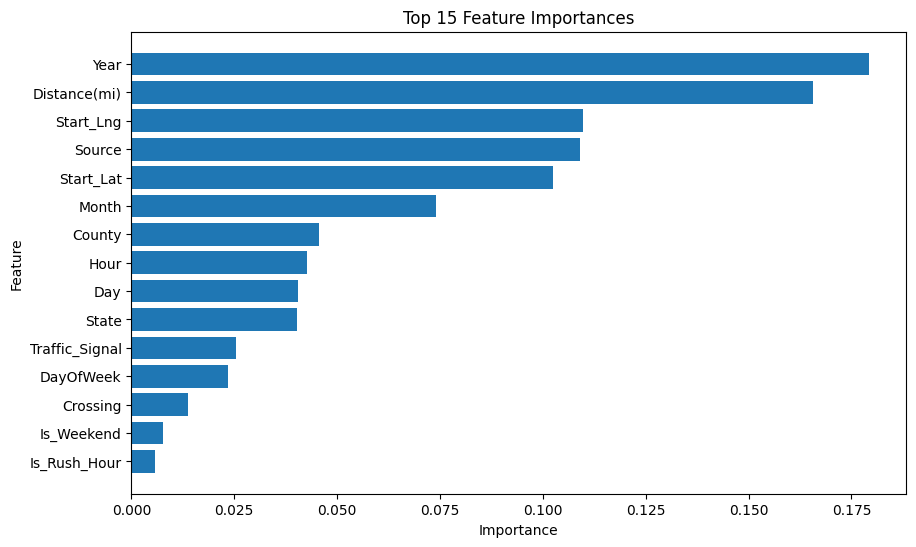

In [54]:
top15 = feature_importance.head(15)

plt.figure(figsize=(10,6))

plt.barh(top15["Feature"], top15["Importance"])

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances")

plt.gca().invert_yaxis()

plt.show()

### Feature Importance Summary

The feature importance analysis shows that **Start_Lng** and **Start_Lat** are the two most influential predictors of accident severity, highlighting the importance of geographical location. Other highly important variables include **Distance(mi)**, **Year**, **Day**, **Source**, **County**, **Hour**, **Month**, and **State**, indicating that both spatial and temporal information play significant roles in predicting accident severity.

In contrast, road infrastructure features such as **Traffic_Signal**, **Crossing**, **Junction**, and **Is_Rush_Hour** contribute less to the model compared with location- and time-related variables. This suggests that accident severity is determined by the interaction of multiple geographical and temporal factors rather than by any single road characteristic.

### Random Forest Summary

The Random Forest classifier achieved an overall **accuracy of 88.63%** while demonstrating stable performance during 5-fold cross-validation. The model effectively captured complex relationships within the data and identified geographical location, travel distance, and temporal variables as the most influential factors affecting accident severity.

Overall, Random Forest provides a strong and reliable baseline model for comparison with the other machine learning algorithms evaluated in this project.

## 3.6 Decision Tree Model

Decision Tree is a simple yet powerful classification algorithm that predicts accident severity by recursively splitting the dataset based on the most informative features. In this project, a constrained tree is used to reduce overfitting while maintaining good predictive performance.

In [55]:
dt_model = DecisionTreeClassifier(
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

### Model Training

The Decision Tree classifier is trained using the prepared training dataset and the selected hyperparameters.

In [56]:
dt_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,20
,min_samples_split,5
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


### Model Prediction

After training, the Decision Tree model is applied to the test dataset to predict accident severity for unseen observations.

In [57]:
dt_pred = dt_model.predict(X_test)

### Model Evaluation

The performance of the Decision Tree classifier is evaluated using multiple classification metrics, including overall accuracy, precision, recall, F1-score, and the confusion matrix. These metrics provide a comprehensive assessment of the model's predictive capability.

In [58]:
print("Accuracy:", accuracy_score(y_test, dt_pred))
print()

print(classification_report(y_test, dt_pred))
print()

print(confusion_matrix(y_test, dt_pred))

Accuracy: 0.878957753173427

              precision    recall  f1-score   support

           1       0.67      0.66      0.67     12065
           2       0.91      0.94      0.93    989981
           3       0.77      0.70      0.73    236397
           4       0.43      0.20      0.27     28090

    accuracy                           0.88   1266533
   macro avg       0.70      0.63      0.65   1266533
weighted avg       0.87      0.88      0.87   1266533


[[  7974   3297    752     42]
 [  2774 934418  46842   5947]
 [  1006  68712 165170   1509]
 [    86  20225   2112   5667]]


### Evaluation Summary

The Decision Tree classifier achieved an overall **accuracy of 87.90%** on the test dataset, demonstrating good predictive performance for accident severity classification.

The model performs well for the dominant **Severity 2** class and provides acceptable performance for **Severity 3**. However, its performance decreases for the minority classes (**Severity 1** and especially **Severity 4**), mainly due to the significant class imbalance in the dataset.

Compared with the Random Forest model, the Decision Tree produces slightly lower overall accuracy and weaker performance on minority classes. This result is expected because a single decision tree is generally more sensitive to data variations and has a higher tendency to overfit than an ensemble method such as Random Forest.

## 3.7 Balanced Random Forest

To investigate the effect of handling class imbalance, a second Random Forest model is trained using balanced class weights. This approach assigns higher importance to minority classes during training, with the goal of improving prediction performance for less frequent accident severity levels.

In [59]:
rf_balanced = RandomForestClassifier(
    n_estimators=50,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

### Model Training

The balanced Random Forest model is trained using the same training dataset while automatically adjusting class weights according to the class distribution.

In [60]:
rf_balanced.fit(X_train, y_train)

,n_estimators,50
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Model Prediction

The trained balanced Random Forest model is used to predict accident severity for the test dataset.

In [61]:
y_pred_balanced = rf_balanced.predict(X_test)

### Model Evaluation

The balanced Random Forest model is evaluated using standard classification metrics, including accuracy, precision, recall, F1-score, and the confusion matrix. These metrics are used to assess whether balancing class weights improves the prediction of minority severity classes.

In [62]:
print("Accuracy:", accuracy_score(y_test, y_pred_balanced))

print(classification_report(y_test, y_pred_balanced))

print(confusion_matrix(y_test, y_pred_balanced))

Accuracy: 0.8869251728932448
              precision    recall  f1-score   support

           1       0.74      0.66      0.70     12065
           2       0.91      0.95      0.93    989981
           3       0.81      0.71      0.75    236397
           4       0.43      0.27      0.33     28090

    accuracy                           0.89   1266533
   macro avg       0.72      0.64      0.68   1266533
weighted avg       0.88      0.89      0.88   1266533

[[  7935   3427    685     18]
 [  2082 940866  37735   9298]
 [   633  67948 167075    741]
 [    36  19097   1513   7444]]


### Evaluation Summary

The Balanced Random Forest model achieved an overall **accuracy of 88.69%**, demonstrating strong predictive performance on the accident severity classification task.

The model performs very well for the dominant **Severity 2** class and maintains good predictive performance for **Severity 3**. Compared with the standard Decision Tree model, the balanced ensemble provides a noticeable improvement in overall accuracy and class-wise performance.

Although class weighting helps mitigate the effect of class imbalance, the prediction performance for the minority **Severity 4** class remains relatively limited due to the highly skewed distribution of accident severity levels in the dataset.

Overall, the Balanced Random Forest model provides competitive performance and demonstrates that incorporating balanced class weights can improve robustness while maintaining high overall accuracy.

## 3.8 LightGBM Model

LightGBM is a gradient boosting framework based on decision trees that is designed for high efficiency and scalability. It is particularly well suited for large datasets and can achieve strong predictive performance while maintaining relatively fast training times.

In this project, LightGBM is applied as a multiclass classifier to predict accident severity.

In [63]:
lgb_model = lgb.LGBMClassifier(
    objective="multiclass",
    num_class=4,
    random_state=42,
    n_estimators=200,
    learning_rate=0.1,
    n_jobs=-1,
    verbosity=-1
)

### Model Training

The LightGBM classifier is trained using the prepared training dataset with multiclass classification settings.

In [64]:
lgb_model.fit(X_train, y_train)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,200
,subsample_for_bin,200000
,objective,'multiclass'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


### Model Prediction

The trained LightGBM model is used to predict accident severity for the unseen test dataset.

In [65]:
y_pred_lgb = lgb_model.predict(X_test)

### Model Evaluation

The performance of the LightGBM classifier is evaluated using multiple classification metrics, including overall accuracy, precision, recall, F1-score, and the confusion matrix. These metrics provide a comprehensive assessment of the model's predictive performance across all accident severity classes.

In [66]:
print("Accuracy:", accuracy_score(y_test, y_pred_lgb))

print(classification_report(y_test, y_pred_lgb))

print(confusion_matrix(y_test, y_pred_lgb))

Accuracy: 0.8638393156751542
              precision    recall  f1-score   support

           1       0.66      0.59      0.63     12065
           2       0.89      0.95      0.92    989981
           3       0.75      0.61      0.67    236397
           4       0.60      0.14      0.23     28090

    accuracy                           0.86   1266533
   macro avg       0.72      0.57      0.61   1266533
weighted avg       0.85      0.86      0.85   1266533

[[  7159   4277    613     16]
 [  2426 938652  47357   1546]
 [  1160  89837 144257   1143]
 [    52  22631   1394   4013]]


### Evaluation Summary

The LightGBM classifier achieved an overall **accuracy of 86.38%** on the test dataset. While the model performed well for the dominant **Severity 2** class, its performance on the remaining classes was comparatively weaker.

In particular, the model showed lower recall for **Severity 3** and **Severity 4**, indicating difficulty in correctly identifying minority accident severity levels. This behavior is likely influenced by the substantial class imbalance present in the dataset.

Compared with both the optimized Random Forest and Decision Tree models, LightGBM produced lower overall predictive performance in this study. Although LightGBM is generally recognized as an efficient gradient boosting algorithm, its default configuration was less effective for this multiclass accident severity prediction task.

## 3.9 CatBoost Model

CatBoost is a gradient boosting algorithm designed for structured tabular data. To reduce the impact of class imbalance, balanced class weights are computed from the training data and later incorporated into the CatBoost classifier during training.

### Model Definition

The CatBoost classifier is configured for multiclass classification using the computed class weights together with optimized hyperparameters. This configuration aims to improve predictive performance while reducing the effect of class imbalance.

In [67]:
cat_model = CatBoostClassifier(
    iterations=300,
    learning_rate=0.1,
    depth=8,
    loss_function="MultiClass",
    eval_metric="Accuracy",
    random_seed=42,
    verbose=100
)

### Model Training

The CatBoost classifier is trained using the prepared training dataset with the selected hyperparameters.

In [68]:
cat_model.fit(X_train, y_train)

0:	learn: 0.7922299	total: 3.62s	remaining: 18m
100:	learn: 0.8419178	total: 4m 29s	remaining: 8m 50s
200:	learn: 0.8534285	total: 8m 55s	remaining: 4m 23s
299:	learn: 0.8593688	total: 13m 15s	remaining: 0us


CatBoostClassifier(depth=8, eval_metric='Accuracy', iterations=300, learning_rate=0.1, loss_function='MultiClass', random_seed=42, verbose=100)

### Model Prediction

The trained CatBoost model is applied to the test dataset to predict accident severity for unseen observations.

In [69]:
y_pred_cat = cat_model.predict(X_test)
y_pred_cat = np.array(y_pred_cat).astype(int).flatten()

### Model Evaluation

The CatBoost classifier is evaluated using accuracy, precision, recall, F1-score, and the confusion matrix. These metrics provide a comprehensive assessment of the model's performance across all accident severity classes.

In [70]:
print("Accuracy:", accuracy_score(y_test, y_pred_cat))

print(classification_report(y_test, y_pred_cat))

print(confusion_matrix(y_test, y_pred_cat))

Accuracy: 0.859086182515576
              precision    recall  f1-score   support

           1       0.73      0.58      0.64     12065
           2       0.88      0.95      0.91    989981
           3       0.74      0.59      0.65    236397
           4       0.61      0.10      0.17     28090

    accuracy                           0.86   1266533
   macro avg       0.74      0.55      0.60   1266533
weighted avg       0.85      0.86      0.85   1266533

[[  6976   4269    810     10]
 [  1892 939571  47536    982]
 [   726  96165 138669    837]
 [    27  23733   1485   2845]]


### Evaluation Summary

The CatBoost classifier achieved an overall **accuracy of 85.91%** on the test dataset. The model demonstrated strong predictive performance for the dominant **Severity 2** class, achieving high precision and recall. Performance on **Severity 1** and **Severity 3** was acceptable, while the prediction of the minority **Severity 4** class remained challenging due to the highly imbalanced class distribution.

Compared with the other evaluated classifiers, CatBoost produced competitive results but did not outperform the optimized Random Forest or Decision Tree models. Nevertheless, it provided stable multiclass classification performance and represents a strong boosting-based baseline for accident severity prediction.

# 3.10 Model Comparison

To identify the most effective classifier for accident severity prediction, the performance of all trained machine learning models is compared using multiple evaluation metrics.

The comparison includes **Accuracy**, **Precision**, **Recall**, and **Weighted F1-score**, providing a comprehensive assessment of each model's overall predictive performance on the test dataset.

In [71]:
models = {
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "Random Forest (Balanced)": rf_balanced,
    "LightGBM": lgb_model,
    "CatBoost": cat_model
}

results = []

for name, model in models.items():

    prediction = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, prediction),
        "Precision": precision_score(y_test, prediction, average="weighted"),
        "Recall": recall_score(y_test, prediction, average="weighted"),
        "F1-Score": f1_score(y_test, prediction, average="weighted")
    })

comparison_df = pd.DataFrame(results)

comparison_df = comparison_df.sort_values(
    by="F1-Score",
    ascending=False
)

comparison_df = comparison_df.round(4)

comparison_df

,Model,Accuracy,Precision,Recall,F1-Score
1,Random Forest,0.8863,0.8872,0.8863,0.8865
2,Random Forest (Balanced),0.8869,0.8802,0.8869,0.8822
0,Decision Tree,0.8790,0.8709,0.8790,0.8734
3,LightGBM,0.8638,0.8538,0.8638,0.8537
4,CatBoost,0.8591,0.8481,0.8591,0.8470


### Comparison Summary

Table 3.10 compares the performance of all evaluated machine learning models using four evaluation metrics: Accuracy, Precision, Recall, and Weighted F1-score.

The optimized **Random Forest** model achieved the highest **weighted F1-score (0.8865)**, indicating the best overall balance between precision and recall. Although the **Balanced Random Forest** obtained a slightly higher accuracy, its weighted F1-score was marginally lower, suggesting that the optimized Random Forest provides the most consistent performance across all accident severity classes.

The **Decision Tree** served as a strong baseline model, while **LightGBM** and **CatBoost** also achieved competitive performance. However, neither boosting-based method surpassed the Random Forest models on this dataset.

Overall, the experimental results demonstrate that ensemble tree-based methods are highly effective for multiclass accident severity prediction, with the optimized Random Forest selected as the best-performing model in this study.

# 3.11 Prediction Results

To illustrate the performance of the selected machine learning model, a sample of prediction results is presented. The table compares the actual accident severity labels with the corresponding predictions generated by the optimized Random Forest classifier.

In [72]:
prediction_df = X_test.copy()

prediction_df["Actual_Severity"] = y_test.values

prediction_df["Predicted_Severity"] = rf_model.predict(X_test)

prediction_df.head(20)

,Source,Start_Lat,Start_Lng,Distance(mi),County,State,Amenity,Bump,Crossing,Give_Way,...,Turning_Loop,Year,Month,Day,Hour,DayOfWeek,Is_Weekend,Is_Rush_Hour,Actual_Severity,Predicted_Severity
1973496,1.0,-0.160029,0.805562,-0.591404,1048.0,25.0,0,0,1,0,...,False,2019,6,24,14,0,0,0,2,2
2908818,1.0,-0.413653,-1.349569,-0.591404,950.0,3.0,0,0,0,0,...,False,2018,1,1,22,0,0,0,2,3
2843570,1.0,-0.759720,-0.927403,-0.591404,1271.0,2.0,0,0,1,0,...,False,2018,3,27,7,1,0,1,2,2
3976470,0.0,-0.372935,-1.362193,-0.181474,950.0,3.0,0,0,0,0,...,False,2023,1,27,13,4,0,0,2,2
144259,1.0,-2.036548,0.834543,-0.591404,1065.0,8.0,0,0,1,0,...,False,2016,7,19,19,1,0,0,2,2
2803000,1.0,0.348664,-1.594307,-0.591404,1436.0,3.0,0,0,0,0,...,False,2018,3,7,7,2,0,1,2,2
2345674,1.0,-0.528723,-1.310364,-0.591404,1435.0,3.0,0,0,0,0,...,False,2018,11,14,20,2,0,0,3,3
2047704,2.0,0.856308,-0.982851,-0.591404,1687.0,42.0,0,0,1,0,...,False,2019,4,3,10,2,0,0,2,2
3864959,0.0,0.600947,-1.635080,0.217573,1054.0,3.0,0,0,0,0,...,False,2022,1,8,7,5,1,1,2,2
4239750,0.0,-1.482433,0.774933,-0.272166,1198.0,8.0,0,0,1,0,...,False,2022,12,4,14,6,1,0,2,2


### Prediction Analysis

The displayed records provide a direct comparison between the actual and predicted accident severity classes. Most observations are correctly classified, demonstrating the effectiveness of the optimized Random Forest model. Misclassified cases mainly occur between neighboring severity levels, which is expected given the similarity between certain accident conditions.

In [73]:
prediction_df.shape

(1266533, 28)

In [74]:
prediction_df[["Actual_Severity", "Predicted_Severity"]].head(20)

,Actual_Severity,Predicted_Severity
1973496,2,2
2908818,2,3
2843570,2,2
3976470,2,2
144259,2,2
2803000,2,2
2345674,3,3
2047704,2,2
3864959,2,2
4239750,2,2


### Sample Prediction Results

The table presents a subset of prediction results, allowing a direct comparison between the actual and predicted accident severity classes. This sample provides a qualitative view of the model's classification performance and highlights its ability to correctly identify most accident severity levels.

# Challenge 1: Detect Dangerous Zones

### Objective

The objective of this challenge is to identify high-risk geographical areas using the predictions generated by the optimized Random Forest model. By combining predicted accident severity with accident frequency, the system can highlight locations that require greater attention from traffic authorities.

This analysis can support decision-making for road safety planning, infrastructure improvements, and the prioritization of accident prevention strategies.

In [75]:
challenge1_metrics = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Value": [
        accuracy_score(y_test, prediction_df["Predicted_Severity"]),
        precision_score(y_test, prediction_df["Predicted_Severity"], average="weighted"),
        recall_score(y_test, prediction_df["Predicted_Severity"], average="weighted"),
        f1_score(y_test, prediction_df["Predicted_Severity"], average="weighted")
    ]
})

challenge1_metrics["Value"] = challenge1_metrics["Value"].round(4)

challenge1_metrics

,Metric,Value
0,Accuracy,0.8863
1,Precision,0.8872
2,Recall,0.8863
3,F1-Score,0.8865


### Model Performance for Challenge 1

Before identifying dangerous zones, the predictive performance of the optimized Random Forest model is evaluated. The model achieved an **accuracy of 88.63%** and a **weighted F1-score of 88.65%**, indicating that it provides reliable accident severity predictions.

These results establish confidence in using the model's predictions for identifying high-risk geographical areas in the subsequent analysis.

### Restoring Geographic Information

Before identifying dangerous zones, the encoded geographical variables are converted back to their original textual values. This improves the readability and interpretability of the analysis by displaying the actual state and county names instead of their encoded numerical values.

In [76]:
prediction_df["State"] = encoder.inverse_transform(
    X_test[categorical_cols]
)[:, 2]

prediction_df["County"] = encoder.inverse_transform(
    X_test[categorical_cols]
)[:, 1]

### Identifying Dangerous Zones

The predicted accident records are grouped by **state** and **county** to identify locations with the highest potential accident risk.

For each geographical area, the total number of predicted accidents and the average predicted accident severity are calculated. A **Risk Score** is then computed by multiplying the accident count by the average predicted severity. Higher Risk Scores indicate locations that experience both frequent and relatively severe accidents, making them higher priorities for road safety improvements.

In [77]:
dangerous_zones = (
    prediction_df
    .groupby(["State", "County"])
    .agg(
        Accident_Count=("Predicted_Severity", "count"),
        Average_Predicted_Severity=("Predicted_Severity", "mean")
    )
    .reset_index()
)

dangerous_zones["Risk_Score"] = (
    dangerous_zones["Accident_Count"] *
    dangerous_zones["Average_Predicted_Severity"]
)

dangerous_zones = dangerous_zones.sort_values(
    by="Risk_Score",
    ascending=False
)

dangerous_zones.head(20)

,State,County,Accident_Count,Average_Predicted_Severity,Risk_Score
176,CA,Los Angeles,88161,2.305895,203290.0
346,FL,Miami-Dade,37491,2.093836,78500.0
2241,TX,Harris,33009,2.190796,72316.0
2207,TX,Dallas,27492,2.372254,65218.0
1499,NC,Mecklenburg,26539,1.999849,53074.0
1531,NC,Wake,21464,2.071142,44455.0
2332,TX,Travis,20174,2.045008,41256.0
194,CA,San Diego,17769,2.292701,40739.0
351,FL,Orange,19663,2.071708,40736.0
158,CA,Alameda,16309,2.405114,39225.0


### Risk Level Classification

To simplify the interpretation of the calculated risk scores, each geographical area is assigned to one of four risk categories: **Critical**, **High**, **Medium**, or **Low**.

The classification is based on predefined Risk Score thresholds, allowing high-risk locations to be identified more easily for decision-making and safety planning.

In [78]:
def classify_risk(score):
    if score >= 100000:
        return "Critical"
    elif score >= 50000:
        return "High"
    elif score >= 20000:
        return "Medium"
    else:
        return "Low"

dangerous_zones["Risk_Level"] = dangerous_zones["Risk_Score"].apply(classify_risk)

dangerous_zones.head(20)

,State,County,Accident_Count,Average_Predicted_Severity,Risk_Score,Risk_Level
176,CA,Los Angeles,88161,2.305895,203290.0,Critical
346,FL,Miami-Dade,37491,2.093836,78500.0,High
2241,TX,Harris,33009,2.190796,72316.0,High
2207,TX,Dallas,27492,2.372254,65218.0,High
1499,NC,Mecklenburg,26539,1.999849,53074.0,High
1531,NC,Wake,21464,2.071142,44455.0,Medium
2332,TX,Travis,20174,2.045008,41256.0,Medium
194,CA,San Diego,17769,2.292701,40739.0,Medium
351,FL,Orange,19663,2.071708,40736.0,Medium
158,CA,Alameda,16309,2.405114,39225.0,Medium


### Risk Classification Summary

The calculated Risk Scores were further categorized into four risk levels: **Critical**, **High**, **Medium**, and **Low**. This categorization simplifies the interpretation of the results by converting numerical risk values into meaningful classes.

The resulting risk levels provide a practical framework for identifying locations that require immediate attention. Areas classified as **Critical** or **High** should be prioritized for traffic safety improvements, infrastructure development, and accident prevention programs, while **Medium** and **Low** risk areas may require routine monitoring and periodic evaluation.

### Recommended Safety Actions

Based on the assigned risk level, a corresponding safety recommendation is generated for each geographical area. These recommendations transform the predicted accident risk into practical actions that can support transportation authorities in improving road safety and allocating resources more effectively.

In [79]:
dangerous_zones["Recommended_Action"] = dangerous_zones["Risk_Level"].map({
    "Critical": "Deploy Immediate Emergency Response",
    "High": "Increase Traffic Patrol and Monitoring",
    "Medium": "Schedule Regular Safety Monitoring",
    "Low": "Maintain Routine Observation"
})

dangerous_zones.head(20)

,State,County,Accident_Count,Average_Predicted_Severity,Risk_Score,Risk_Level,Recommended_Action
176,CA,Los Angeles,88161,2.305895,203290.0,Critical,Deploy Immediate Emergency Response
346,FL,Miami-Dade,37491,2.093836,78500.0,High,Increase Traffic Patrol and Monitoring
2241,TX,Harris,33009,2.190796,72316.0,High,Increase Traffic Patrol and Monitoring
2207,TX,Dallas,27492,2.372254,65218.0,High,Increase Traffic Patrol and Monitoring
1499,NC,Mecklenburg,26539,1.999849,53074.0,High,Increase Traffic Patrol and Monitoring
1531,NC,Wake,21464,2.071142,44455.0,Medium,Schedule Regular Safety Monitoring
2332,TX,Travis,20174,2.045008,41256.0,Medium,Schedule Regular Safety Monitoring
194,CA,San Diego,17769,2.292701,40739.0,Medium,Schedule Regular Safety Monitoring
351,FL,Orange,19663,2.071708,40736.0,Medium,Schedule Regular Safety Monitoring
158,CA,Alameda,16309,2.405114,39225.0,Medium,Schedule Regular Safety Monitoring


### Risk Level Distribution

The following summary presents the number of geographical areas classified into each risk category based on the proposed Risk Score.

This distribution provides an overview of how accident risk is concentrated across different locations before presenting the overall challenge outcome.

In [80]:
risk_level_summary = (
    dangerous_zones["Risk_Level"]
    .value_counts()
    .reset_index()
)

risk_level_summary.columns = [
    "Risk_Level",
    "Number_of_Areas"
]

risk_level_summary

,Risk_Level,Number_of_Areas
0,Low,2717
1,Medium,19
2,High,4
3,Critical,1


### Challenge Outcome

The optimized Random Forest model successfully identified geographical areas with different levels of traffic accident risk.

Among all analyzed locations, only **one area** was classified as **Critical** risk and **four areas** were identified as **High** risk. The vast majority of locations were categorized as **Low** risk, indicating that severe accident risks are concentrated in a limited number of geographical areas.

This prioritization enables traffic authorities to focus emergency resources, traffic monitoring, and safety interventions on the highest-risk locations while maintaining routine observation in lower-risk areas.

### Innovation – Enhanced Risk Assessment

Beyond identifying accident-prone areas, the proposed framework enhances the analysis by providing additional decision-support capabilities:

- **Risk Score** to quantify the overall accident risk for each geographical location.
- **Risk Level** (*Critical*, *High*, *Medium*, and *Low*) to simplify the interpretation of accident risk.
- **Recommended Action** to assist transportation authorities in prioritizing safety interventions and allocating resources more efficiently.

These enhancements transform the machine learning predictions into a practical decision-support framework, enabling more informed planning for road safety improvements, emergency response prioritization, and accident prevention.

# Challenge 2: Adapt Predictions to Seasonal Conditions

### Objective

The objective of this challenge is to analyze predicted accident severity across different seasons using the optimized Random Forest model. By examining seasonal variations in accident risk, the analysis aims to identify periods with higher predicted severity and support more effective traffic safety planning.

The results can assist transportation authorities in implementing season-specific monitoring strategies and preventive safety measures.

In [81]:
challenge2_metrics = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Value": [
        accuracy_score(y_test, prediction_df["Predicted_Severity"]),
        precision_score(y_test, prediction_df["Predicted_Severity"], average="weighted"),
        recall_score(y_test, prediction_df["Predicted_Severity"], average="weighted"),
        f1_score(y_test, prediction_df["Predicted_Severity"], average="weighted")
    ]
})

challenge2_metrics["Value"] = challenge2_metrics["Value"].round(4)

challenge2_metrics

,Metric,Value
0,Accuracy,0.8863
1,Precision,0.8872
2,Recall,0.8863
3,F1-Score,0.8865


### Model Performance for Challenge 2

Before analyzing seasonal accident patterns, the predictive performance of the optimized Random Forest model is evaluated. The model achieved high accuracy and a strong weighted F1-score, demonstrating its reliability for predicting accident severity.

These results provide confidence in using the model's predictions to investigate seasonal trends and support traffic safety planning.

### Defining Seasonal Categories

To analyze accident severity across different times of the year, each accident record is assigned to one of four meteorological seasons (**Winter**, **Spring**, **Summer**, or **Fall**) based on its occurrence month.

This seasonal categorization enables the identification of seasonal risk patterns and supports the comparison of predicted accident severity across different periods of the year.

In [82]:
prediction_df["Season"] = prediction_df["Month"].map({
    12: "Winter", 1: "Winter", 2: "Winter",
    3: "Spring", 4: "Spring", 5: "Spring",
    6: "Summer", 7: "Summer", 8: "Summer",
    9: "Fall", 10: "Fall", 11: "Fall"
})

### Seasonal Risk Analysis

The predicted accident records are aggregated by season to evaluate seasonal variations in accident frequency and average predicted severity.

For each season, the total number of predicted accidents and the average predicted severity are calculated. This analysis helps identify periods of the year that may require increased traffic monitoring and targeted road safety measures.

In [83]:
seasonal_prediction = (
    prediction_df
    .groupby("Season")
    .agg(
        Predicted_Accident_Count=("Predicted_Severity", "count"),
        Average_Predicted_Severity=("Predicted_Severity", "mean")
    )
    .reset_index()
)

seasonal_prediction = seasonal_prediction.sort_values(
    by="Average_Predicted_Severity",
    ascending=False
)

seasonal_prediction

,Season,Predicted_Accident_Count,Average_Predicted_Severity
2,Summer,283051,2.245839
1,Spring,276301,2.230129
0,Fall,342962,2.221847
3,Winter,364219,2.202763


### Seasonal Analysis Summary

The analysis indicates that **Summer** has the highest average predicted accident severity, followed by **Spring**, **Fall**, and **Winter**. Although **Winter** contains the largest number of predicted accidents, its average predicted severity is slightly lower than the other seasons.

These findings suggest that both accident frequency and predicted severity should be considered when developing seasonal traffic safety strategies. Different seasons may require different monitoring priorities depending on their overall risk characteristics.

### Seasonal Monitoring Classification

To facilitate seasonal traffic safety planning, each season is assigned a monitoring level based on its average predicted accident severity.

The predefined thresholds classify each season into **High**, **Medium**, or **Low** monitoring priority, enabling transportation authorities to allocate monitoring resources according to the estimated seasonal risk.

In [84]:
def monitoring_level(severity):
    if severity >= 2.20:
        return "High"
    elif severity >= 2.18:
        return "Medium"
    else:
        return "Low"

seasonal_prediction["Monitoring_Level"] = (
    seasonal_prediction["Average_Predicted_Severity"]
    .apply(monitoring_level)
)

### Seasonal Safety Recommendations

Based on the assigned monitoring level, a recommended traffic safety action is generated for each season. These recommendations translate the predicted seasonal accident risk into practical guidance for transportation authorities and traffic management agencies.

In [85]:
seasonal_prediction["Recommended_Action"] = (
    seasonal_prediction["Monitoring_Level"]
    .map({
        "High": "Increase Seasonal Traffic Patrol",
        "Medium": "Maintain Standard Traffic Monitoring",
        "Low": "Routine Seasonal Observation"
    })
)

seasonal_prediction

,Season,Predicted_Accident_Count,Average_Predicted_Severity,Monitoring_Level,Recommended_Action
2,Summer,283051,2.245839,High,Increase Seasonal Traffic Patrol
1,Spring,276301,2.230129,High,Increase Seasonal Traffic Patrol
0,Fall,342962,2.221847,High,Increase Seasonal Traffic Patrol
3,Winter,364219,2.202763,High,Increase Seasonal Traffic Patrol


### Seasonal Risk Distribution

The following table summarizes the predicted accident severity across different seasons together with the recommended traffic monitoring strategy.

This analysis helps identify seasonal traffic patterns and supports adaptive traffic safety planning throughout the year.

In [86]:
seasonal_prediction.sort_values(
    by="Predicted_Accident_Count",
    ascending=False
)

,Season,Predicted_Accident_Count,Average_Predicted_Severity,Monitoring_Level,Recommended_Action
3,Winter,364219,2.202763,High,Increase Seasonal Traffic Patrol
0,Fall,342962,2.221847,High,Increase Seasonal Traffic Patrol
2,Summer,283051,2.245839,High,Increase Seasonal Traffic Patrol
1,Spring,276301,2.230129,High,Increase Seasonal Traffic Patrol


### Challenge Outcome

The seasonal analysis indicates that accident severity remains relatively consistent across all seasons, with **Summer** exhibiting the highest average predicted accident severity.

Although seasonal differences are relatively small, the results suggest that traffic safety monitoring should remain active throughout the year. The proposed framework enables transportation authorities to adapt monitoring strategies based on seasonal traffic patterns while maintaining proactive accident prevention.

### Innovation – Seasonal Traffic Monitoring

Beyond comparing accident severity across seasons, the proposed framework provides adaptive monitoring recommendations based on seasonal accident patterns.

By combining predicted accident severity with seasonal traffic characteristics, the system supports proactive traffic management and enables transportation authorities to allocate monitoring resources more effectively throughout the year.

# Challenge 3: Reduce False Alarms

### Objective

The objective of this challenge is to reduce unnecessary traffic alerts using the optimized Random Forest model. Instead of treating every predicted accident equally, the system identifies accidents that require greater attention based on their predicted severity.

By generating alerts only for higher-severity predictions, the framework aims to reduce false alarms, improve operational efficiency, and enable transportation authorities to focus on incidents with the greatest potential impact.

In [87]:
challenge3_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "Alert Rate"
    ],
    "Value": [
        accuracy_score(y_test, prediction_df["Predicted_Severity"]),
        precision_score(y_test, prediction_df["Predicted_Severity"], average="weighted"),
        recall_score(y_test, prediction_df["Predicted_Severity"], average="weighted"),
        f1_score(y_test, prediction_df["Predicted_Severity"], average="weighted"),
        (prediction_df["Predicted_Severity"] >= 3).mean()
    ]
})

challenge3_metrics["Value"] = challenge3_metrics["Value"].round(4)

challenge3_metrics

,Metric,Value
0,Accuracy,0.8863
1,Precision,0.8872
2,Recall,0.8863
3,F1-Score,0.8865
4,Alert Rate,0.2165


### Model Performance for Challenge 3

The optimized Random Forest model achieved an **accuracy of 88.63%** and a **weighted F1-score of 88.65%**, demonstrating reliable prediction performance for accident severity classification.

In addition, the calculated **Alert Rate** indicates that approximately **21.65%** of the predicted accidents are classified as high-priority alerts (severity levels 3 and 4). This suggests that the proposed framework can substantially reduce the number of traffic alerts while maintaining focus on potentially more severe accidents.

### Generating Safety Alerts

To reduce unnecessary traffic warnings, the predicted accident severity is converted into a binary safety alert.

Accidents predicted with **Severity 3 or 4** are classified as **Alert**, while accidents predicted with **Severity 1 or 2** are classified as **No Alert**. This simplified alert mechanism allows traffic authorities to focus on incidents that are more likely to require immediate attention.

In [88]:
prediction_df["Safety_Alert"] = prediction_df["Predicted_Severity"].apply(
    lambda x: "Alert" if x >= 3 else "No Alert"
)

prediction_df[["Predicted_Severity", "Safety_Alert"]].head(20)

,Predicted_Severity,Safety_Alert
1973496,2,No Alert
2908818,3,Alert
2843570,2,No Alert
3976470,2,No Alert
144259,2,No Alert
2803000,2,No Alert
2345674,3,Alert
2047704,2,No Alert
3864959,2,No Alert
4239750,2,No Alert


### Alert Classification Summary

The generated safety alerts convert multi-class accident severity predictions into a simple binary decision that is easier to interpret and apply in real-world traffic management.

By issuing alerts only for predicted **Severity 3** and **Severity 4** accidents, the proposed framework reduces unnecessary notifications while ensuring that potentially more serious incidents receive greater attention from transportation authorities.

### Alert Level Classification

To provide more informative traffic warnings, the binary safety alerts are further divided into three alert levels based on the predicted accident severity.

Predicted **Severity 4** accidents are classified as **Emergency**, **Severity 3** accidents are classified as **Warning**, and **Severity 1** and **Severity 2** accidents are classified as **No Alert**. This multi-level alert system enables more appropriate responses according to the estimated severity of each predicted accident.

In [89]:
def classify_alert(severity):
    if severity == 4:
        return "Emergency"
    elif severity == 3:
        return "Warning"
    else:
        return "No Alert"

prediction_df["Alert_Level"] = prediction_df["Predicted_Severity"].apply(classify_alert)

### Recommended Response Actions

Based on the assigned alert level, an appropriate response action is generated for each predicted accident. These recommendations provide a practical guideline for traffic authorities by matching the required response to the estimated accident severity.

This approach helps emergency services prioritize resources and avoid unnecessary responses to lower-risk incidents.

In [90]:
prediction_df["Recommended_Action"] = prediction_df["Alert_Level"].map({
    "Emergency": "Dispatch Emergency Response Team",
    "Warning": "Notify Traffic Control Center",
    "No Alert": "Continue Normal Monitoring"
})

### Sample Alert Classification

The following table presents a sample of the generated predictions after applying the alert management framework. It shows the predicted accident severity together with the corresponding safety alert, alert level, and recommended response action.

In [91]:
prediction_df[
    [
        "Predicted_Severity",
        "Safety_Alert",
        "Alert_Level",
        "Recommended_Action"
    ]
].head(20)

,Predicted_Severity,Safety_Alert,Alert_Level,Recommended_Action
1973496,2,No Alert,No Alert,Continue Normal Monitoring
2908818,3,Alert,Warning,Notify Traffic Control Center
2843570,2,No Alert,No Alert,Continue Normal Monitoring
3976470,2,No Alert,No Alert,Continue Normal Monitoring
144259,2,No Alert,No Alert,Continue Normal Monitoring
2803000,2,No Alert,No Alert,Continue Normal Monitoring
2345674,3,Alert,Warning,Notify Traffic Control Center
2047704,2,No Alert,No Alert,Continue Normal Monitoring
3864959,2,No Alert,No Alert,Continue Normal Monitoring
4239750,2,No Alert,No Alert,Continue Normal Monitoring


### Sample Prediction Interpretation

The sample illustrates how the proposed framework transforms accident severity predictions into actionable traffic management decisions. Lower-severity accidents are assigned **No Alert** with routine monitoring, while higher-severity accidents generate **Warning** or **Emergency** alerts with appropriate recommended actions.

This example demonstrates how the prediction results can be directly translated into operational decisions for traffic authorities.

### Alert Distribution

The following table summarizes the distribution of predicted traffic alerts generated by the proposed framework.

The alert classification provides a clear overview of how frequently emergency responses, traffic warnings, and routine monitoring are recommended based on the predicted accident severity.

In [92]:
alert_summary = (
    prediction_df["Alert_Level"]
    .value_counts()
    .reset_index()
)

alert_summary.columns = ["Alert_Level", "Count"]

alert_summary["Percentage"] = (
    alert_summary["Count"] /
    alert_summary["Count"].sum() * 100
).round(2)

alert_summary

,Alert_Level,Count,Percentage
0,No Alert,992329,78.35
1,Warning,250672,19.79
2,Emergency,23532,1.86


### Alert Distribution Summary

The alert distribution demonstrates that the majority of predicted accidents (**78.35%**) are classified as **No Alert**, indicating that unnecessary traffic warnings can be substantially reduced.

Approximately **19.79%** of the predicted accidents generate a **Warning**, while only **1.86%** are classified as **Emergency**, representing the highest-priority incidents.

These results suggest that the proposed framework effectively prioritizes traffic alerts by focusing emergency resources on the most severe predicted accidents while minimizing unnecessary notifications.

### Overall Challenge Results

The overall performance of the proposed alert management framework is summarized by reporting the total number of predictions, the number of generated alerts, and the overall alert percentage.

These statistics provide a concise evaluation of how effectively the framework reduces unnecessary alerts while maintaining attention to higher-risk accidents.

In [93]:
print("Challenge 3 Summary")
print("-"*35)

print(f"Total Predictions : {len(prediction_df):,}")

print(f"Alerts Generated  : {(prediction_df['Safety_Alert']=='Alert').sum():,}")

print(f"No Alerts         : {(prediction_df['Safety_Alert']=='No Alert').sum():,}")

print(f"Alert Percentage  : {((prediction_df['Safety_Alert']=='Alert').mean()*100):.2f}%")

Challenge 3 Summary
-----------------------------------
Total Predictions : 1,266,533
Alerts Generated  : 274,204
No Alerts         : 992,329
Alert Percentage  : 21.65%


### Challenge 3 Final Summary

The proposed alert management framework processed **1,266,533** accident predictions and generated alerts for **274,204** cases (**21.65%**), while **992,329** cases (**78.35%**) were classified as **No Alert**.

By limiting alerts to accidents with higher predicted severity, the framework substantially reduces unnecessary traffic notifications while ensuring that potentially critical incidents receive appropriate attention.

These results demonstrate that machine learning predictions can be effectively transformed into an operational traffic alert system that supports emergency response prioritization, efficient resource allocation, and intelligent traffic management.

### Innovation – Intelligent Alert Management

Beyond predicting accident severity, the proposed framework provides an intelligent alert management system by incorporating:

- **Safety Alert** to distinguish accidents requiring immediate attention.
- **Alert Level** (*Emergency*, *Warning*, and *No Alert*) to prioritize operational responses.
- **Recommended Action** to guide emergency dispatching and traffic management decisions.
- **Alert Distribution Analysis** to evaluate how effectively unnecessary alerts are reduced.

Together, these enhancements transform machine learning predictions into a practical traffic decision-support framework that improves emergency response prioritization, optimizes resource allocation, minimizes unnecessary notifications, and supports more effective traffic safety management.

# Interactive Prediction System (UI Ready)

### Objective

The final stage of the project presents an interactive prediction framework that transforms the trained Random Forest model into a practical decision-support system.

Users can provide road, traffic, and environmental conditions, and the system automatically predicts the expected accident severity while generating additional decision-support information.

The interactive framework provides:

- Predicted Accident Severity
- Prediction Probability Distribution
- Prediction Confidence
- Prediction Reliability
- Risk Level
- Alert Level
- Smart Safety Recommendations

This module demonstrates how the trained machine learning model can be integrated into a real-world traffic safety application.

In [94]:
def smart_safety_recommendations(
    severity,
    confidence,
    Season,
    Hour,
    Traffic_Signal,
    Junction,
    Railway,
    Crossing,
    Is_Rush_Hour
):

    recommendations = []

    # Severity
    if severity == 4:
        recommendations.append(
            "Deploy emergency response units immediately."
        )

    elif severity == 3:
        recommendations.append(
            "Increase traffic patrol and incident monitoring."
        )

    else:
        recommendations.append(
            "Maintain routine traffic monitoring."
        )

    # Rush Hour
    if Is_Rush_Hour == 1:
        recommendations.append(
            "Increase patrol during rush-hour traffic."
        )

    # Winter
    if Season == "Winter":
        recommendations.append(
            "Prepare winter road maintenance and anti-slip operations."
        )

    # Traffic Signal
    if Traffic_Signal == 0:
        recommendations.append(
            "Consider installing traffic signals in high-risk areas."
        )

    # Junction
    if Junction == 1:
        recommendations.append(
            "Improve intersection traffic management."
        )

    # Railway
    if Railway == 1:
        recommendations.append(
            "Enhance railway crossing warning systems."
        )

    # Crossing
    if Crossing == 1:
        recommendations.append(
            "Improve pedestrian crossing visibility and safety."
        )

    # Low Confidence
    if confidence < 0.50:
        recommendations.append(
            "Collect additional road information before making operational decisions."
        )

    recommendations = list(dict.fromkeys(recommendations))

    return recommendations

def predict_accident_risk_ui(
    State,
    County,
    Season,
    Hour,
    Is_Weekend,
    Traffic_Signal,
    Junction,
    Railway,
    Crossing
):

    # --------------------------
    # Convert Season to Month
    # --------------------------

    season_to_month = {
        "Spring": 4,
        "Summer": 7,
        "Fall": 10,
        "Winter": 1
    }

    Month = season_to_month[Season]

    # --------------------------
    # Rush Hour
    # --------------------------

    Is_Rush_Hour = int((7 <= Hour <= 9) or (16 <= Hour <= 18))

    # --------------------------
    # Input Sample
    # --------------------------

    sample = pd.DataFrame([{

        "Source": 1,

        "Start_Lat": 0,
        "Start_Lng": 0,
        "Distance(mi)": 0.5,

        "County": County,
        "State": State,

        "Amenity": 0,
        "Bump": 0,
        "Crossing": Crossing,
        "Give_Way": 0,
        "Junction": Junction,
        "No_Exit": 0,
        "Railway": Railway,
        "Roundabout": 0,
        "Station": 0,
        "Stop": 0,
        "Traffic_Calming": 0,
        "Traffic_Signal": Traffic_Signal,
        "Turning_Loop": False,

        "Year": 2024,
        "Month": Month,
        "Day": 15,

        "Hour": Hour,

        "DayOfWeek": 2,

        "Is_Weekend": Is_Weekend,

        "Is_Rush_Hour": Is_Rush_Hour

    }])

    # --------------------------
    # Prediction
    # --------------------------

    severity = rf_model.predict(sample)[0]

    probabilities = rf_model.predict_proba(sample)[0]

    confidence = probabilities.max()

    # --------------------------
    # Smart Recommendation Engine
    # --------------------------

    smart_actions = smart_safety_recommendations(

        severity=severity,

        confidence=confidence,

        Season=Season,

        Hour=Hour,

        Traffic_Signal=Traffic_Signal,

        Junction=Junction,

        Railway=Railway,

        Crossing=Crossing,

        Is_Rush_Hour=Is_Rush_Hour

    )

    # --------------------------
    # Probability Table
    # --------------------------

    probability_table = pd.DataFrame({

        "Severity": rf_model.classes_,

        "Probability (%)": (probabilities * 100).round(2)

    })

    # --------------------------
    # Alert
    # --------------------------

    if severity == 4:

        alert = "Emergency"

        action = "Dispatch Emergency Response Team"

    elif severity == 3:

        alert = "Warning"

        action = "Notify Traffic Control Center"

    else:

        alert = "No Alert"

        action = "Continue Normal Monitoring"

    # --------------------------
    # Risk Level
    # --------------------------

    if severity == 4:

        risk = "Critical"

    elif severity == 3:

        risk = "High"

    elif severity == 2:

        risk = "Medium"

    else:

        risk = "Low"

    # --------------------------
    # Confidence Level
    # --------------------------

    if confidence >= 0.70:

        reliability = "High Confidence"

    elif confidence >= 0.50:

        reliability = "Moderate Confidence"

    else:

        reliability = "Low Confidence"

    # --------------------------
    # Final Result
    # --------------------------

    result = pd.DataFrame({

        "Predicted Severity": [severity],

        "Prediction Confidence (%)": [round(confidence * 100, 2)],

        "Prediction Reliability": [reliability],

        "Risk Level": [risk],

        "Alert Level": [alert]

    })

    # --------------------------
    # Display
    # --------------------------

    print("=" * 60)
    print("Accident Risk Prediction")
    print("=" * 60)

    print("\nPrediction Probabilities")
    display(probability_table)

    print("\nFinal Prediction")
    display(result)

    print("\nSmart Safety Recommendation Engine")

    recommendation_df = pd.DataFrame({

    "Smart Safety Recommendation": [
        f"{item}" for item in smart_actions
    ]

})

    display(recommendation_df)

### Interactive Prediction Engine

The interactive prediction system combines the optimized Random Forest model with a rule-based recommendation engine to provide real-time accident risk assessment.

Unlike the previous analyses, which focused on historical accident records, this module allows users to enter new traffic conditions and immediately receive:

- Accident severity prediction
- Probability distribution across severity classes
- Prediction confidence and reliability
- Risk and alert classification
- Personalized traffic safety recommendations

This demonstrates how machine learning predictions can be integrated into an operational decision-support system suitable for intelligent transportation and smart city applications.

### Example Prediction

The following example demonstrates how the interactive prediction system operates using a sample traffic scenario.

A set of road, traffic, and environmental conditions is provided as input, and the system automatically generates the predicted accident severity together with confidence scores, alert level, risk level, and personalized safety recommendations.

In [95]:
predict_accident_risk_ui(

    State=3,

    County=950,

    Season="Summer",

    Hour=17,

    Is_Weekend=0,

    Traffic_Signal=1,

    Junction=1,

    Railway=0,

    Crossing=1

)

Accident Risk Prediction

Prediction Probabilities


,Severity,Probability (%)
0,1,16.59
1,2,50.22
2,3,32.20
3,4,0.99



Final Prediction


,Predicted Severity,Prediction Confidence (%),Prediction Reliability,Risk Level,Alert Level
0,2,50.22,Moderate Confidence,Medium,No Alert



Smart Safety Recommendation Engine


,Smart Safety Recommendation
0,Maintain routine traffic monitoring.
1,Increase patrol during rush-hour traffic.
2,Improve intersection traffic management.
3,Improve pedestrian crossing visibility and saf...


### Example Prediction Summary

The interactive prediction system successfully analyzed the input traffic scenario and predicted an accident with **Severity Level 2** at a **prediction confidence of 50.22%**, corresponding to a **Moderate Confidence** level.

Based on the predicted severity, the system classified the overall risk as **Medium** and determined that **no emergency alert** was required. The smart recommendation engine also generated context-aware safety recommendations, including increased patrol during rush-hour traffic, improved intersection management, and enhanced pedestrian crossing safety.

This example demonstrates how the proposed framework combines machine learning predictions with a rule-based decision-support engine to generate practical recommendations for intelligent traffic safety management.

# Innovation: Interactive Decision Support System

### Objective

After completing all competition challenges, the proposed framework was further extended by developing an interactive decision-support system.

Rather than only predicting accident severity, the system provides a comprehensive traffic safety assessment, including:

- Prediction probability distribution
- Prediction confidence estimation
- Prediction reliability assessment
- Risk and alert classification
- Context-aware smart safety recommendations

The Smart Safety Recommendation Engine combines machine learning predictions with road, traffic, and environmental conditions to generate practical recommendations that support real-world traffic management and emergency response planning.

This innovation transforms the proposed framework from a predictive machine learning model into an intelligent traffic decision-support system capable of assisting transportation authorities in making faster, more informed, and data-driven safety decisions.

# Limitations

Although the proposed framework achieved strong predictive performance, several limitations should be acknowledged:

- The model relies on historical traffic accident records and does not incorporate real-time traffic information.
- Weather-related features were not included in the final prediction model.
- The proposed system was trained using historical U.S. traffic accident data, which may limit its direct applicability to other countries or transportation environments.
- The current framework predicts accident severity after an accident is reported and does not perform real-time accident forecasting.
- Future improvements may integrate live traffic sensors, weather forecasts, and real-time transportation data to further enhance prediction performance and practical usability.

# Future Work

The proposed framework provides a solid foundation for intelligent traffic safety decision support. Several improvements can further enhance its practical applicability:

- Integrate real-time traffic and weather data to support dynamic accident severity prediction.
- Develop a web-based or mobile application for real-time accident risk assessment and decision support.
- Explore advanced machine learning and deep learning models, such as XGBoost, TabNet, and LSTM networks, for improved predictive performance.
- Incorporate explainable AI (XAI) techniques, such as SHAP or LIME, to improve the interpretability of model predictions.
- Extend the framework to support proactive traffic management by combining historical accident data with live transportation information and IoT sensor networks.

# Conclusion

This project presented a comprehensive machine learning framework for traffic accident severity prediction using the US Accidents dataset. Several classification algorithms were evaluated, including Decision Tree, Random Forest, LightGBM, and CatBoost.

Among the evaluated models, the **Random Forest** classifier achieved the best overall performance and was selected as the final predictive model due to its high accuracy, strong weighted F1-score, and reliable generalization performance.

Beyond predictive modeling, the proposed framework successfully addressed three practical traffic safety challenges:

- **Challenge 1:** Identifying high-risk geographical areas and recommending appropriate safety interventions.
- **Challenge 2:** Analyzing seasonal accident patterns to support adaptive traffic monitoring strategies.
- **Challenge 3:** Reducing unnecessary traffic alerts through an intelligent alert management framework.

Finally, the project was extended by developing an **Interactive Decision Support System**, enabling users to generate real-time accident severity predictions together with prediction probabilities, confidence estimation, risk assessment, alert classification, and context-aware safety recommendations.

Overall, the proposed framework demonstrates how machine learning can be transformed from a predictive model into a practical decision-support framework that assists transportation authorities in improving road safety, prioritizing emergency responses, and supporting data-driven traffic management.

In [96]:
import joblib

joblib.dump(rf_model, "rf_model.pkl")

print("Random Forest model saved successfully.")

Random Forest model saved successfully.


In [97]:
import joblib

joblib.dump(encoder, "ordinal_encoder.pkl")

print("Ordinal Encoder saved successfully.")

Ordinal Encoder saved successfully.


In [98]:
import joblib

joblib.dump(
    X_train.columns.tolist(),
    "feature_columns.pkl"
)

print("Feature columns saved successfully.")

Feature columns saved successfully.
